In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded.")
print(f"Pandas version: {pd.__version__}")

Libraries loaded.
Pandas version: 3.0.2


In [3]:
# ============================================
# LOAD ALL CLEANED DATASETS
# ============================================

cleaned_path = '../data/cleaned/'

# Load each file into its own named DataFrame
electricity_source = pd.read_csv(f'{cleaned_path}GHS2022_electricity_main_source_cleaned.csv')
electricity_access = pd.read_csv(f'{cleaned_path}GHS2022_electricity_access_cleaned.csv')
water_source = pd.read_csv(f'{cleaned_path}GHS2022_water_main_source_cleaned.csv')
water_supply = pd.read_csv(f'{cleaned_path}GHS2022_water_supply_cleaned.csv')
water_distance = pd.read_csv(f'{cleaned_path}GHS2022_water_distance_cleaned.csv')
toilet_type = pd.read_csv(f'{cleaned_path}GHS2022_toilet_type_cleaned.csv')
toilet_distance = pd.read_csv(f'{cleaned_path}GHS2022_toilet_distance_cleaned.csv')
refuse_removal = pd.read_csv(f'{cleaned_path}GHS2022_refuse_removal_cleaned.csv')
refuse_irregular = pd.read_csv(f'{cleaned_path}GHS2022_refuse_irregular_cleaned.csv')
handwashing = pd.read_csv(f'{cleaned_path}GHS2022_handwashing_cleaned.csv')
dwelling_type = pd.read_csv(f'{cleaned_path}GHS2022_dwelling_type_cleaned.csv')
dwelling_built = pd.read_csv(f'{cleaned_path}GHS2022_dwelling_built_cleaned.csv')

# Quick confirmation all loaded correctly
datasets = {
    'electricity_source': electricity_source,
    'electricity_access': electricity_access,
    'water_source': water_source,
    'water_supply': water_supply,
    'water_distance': water_distance,
    'toilet_type': toilet_type,
    'toilet_distance': toilet_distance,
    'refuse_removal': refuse_removal,
    'refuse_irregular': refuse_irregular,
    'handwashing': handwashing,
    'dwelling_type': dwelling_type,
    'dwelling_built': dwelling_built
}

print("Datasets loaded:")
for name, df in datasets.items():
    print(f"  {name}: {df.shape}")

Datasets loaded:
  electricity_source: (72, 3)
  electricity_access: (27, 3)
  water_source: (126, 3)
  water_supply: (36, 3)
  water_distance: (54, 3)
  toilet_type: (117, 3)
  toilet_distance: (54, 3)
  refuse_removal: (108, 3)
  refuse_irregular: (27, 3)
  handwashing: (45, 3)
  dwelling_type: (108, 3)
  dwelling_built: (81, 3)


In [4]:
# What categories exist in refuse removal?
print(refuse_removal['refuse_type'].unique)
print(f"\nTotal rows: {len(refuse_removal)}")
print(f"\nSample data:")
print(refuse_removal.head(15))

<bound method Series.unique of 0      Removed by local authority/private company at ...
1      Removed by local authority/private company les...
2      Removed by community members; contracted by th...
3      Removed by community members; contracted by th...
4      Removed by community members at least once a week
                             ...                        
103          Communal container/central collection point
104                                      Own refuse dump
105                       Dump or leave rubbish anywhere
106                                                Other
107                                          Unspecified
Name: refuse_type, Length: 108, dtype: str>

Total rows: 108

Sample data:
        province                                        refuse_type    count
0   Western Cape  Removed by local authority/private company at ...  6399265
1   Western Cape  Removed by local authority/private company les...    65665
2   Western Cape  Removed by communi

In [5]:
# Get the exact category name we want
# Filter for rows containing our target phrase
target_rows = refuse_removal[
    refuse_removal['refuse_type'].str.contains('local authority', case=False)
]
print(target_rows['refuse_type'].unique())

<StringArray>
['Removed by local authority/private company at least once a week', 'Removed by local authority/private company less often than once a week']
Length: 2, dtype: str


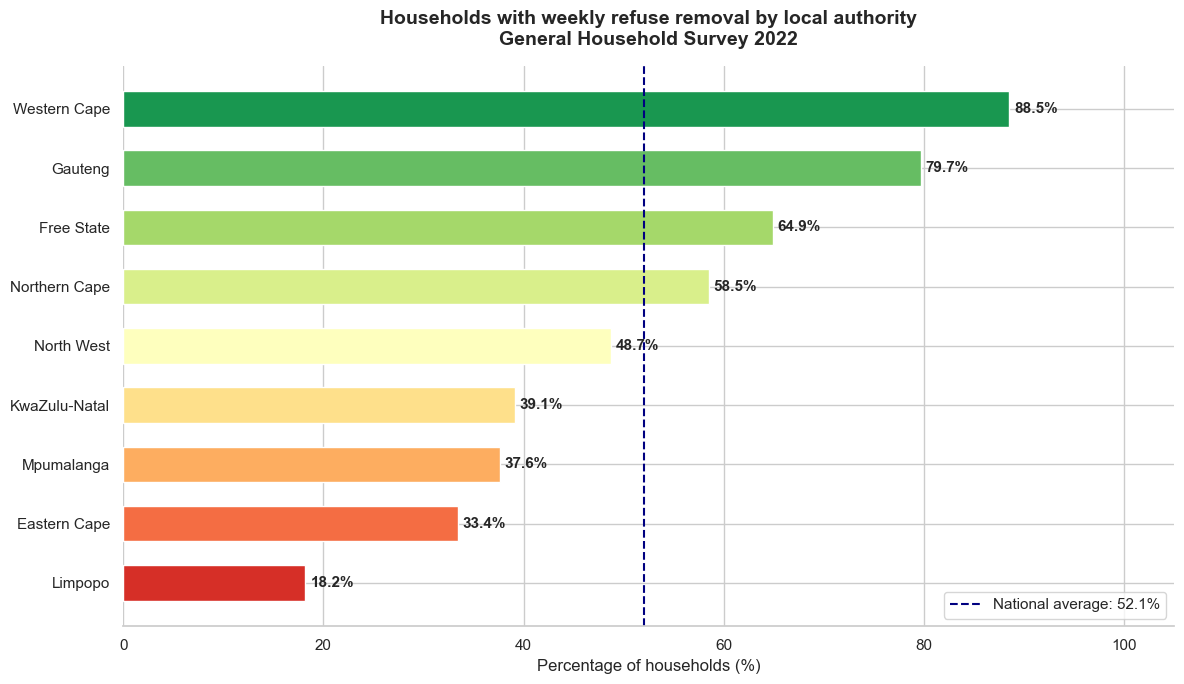


Data behind the chart:
     province    count  percentage
 Western Cape  6399265        88.5
      Gauteng 12960040        79.7
   Free State  1948001        64.9
Northern Cape   756812        58.5
   North West  2046512        48.7
KwaZulu-Natal  4625584        39.1
   Mpumalanga  1824867        37.6
 Eastern Cape  2182618        33.4
      Limpopo  1124471        18.2


In [6]:
# ============================================
# CHART 1 — Refuse removed by local authority
# at least once a week by province
# ============================================

# Step 1 — Filter for our target category
weekly_removal = refuse_removal[
    refuse_removal['refuse_type'] == 
    'Removed by local authority/private company at least once a week'
].copy()

# Step 2 — Calculate percentage of total per province
# First get total households per province across all refuse types
province_totals = refuse_removal.groupby('province')['count'].sum()

# Add total to our filtered data
weekly_removal['total'] = weekly_removal['province'].map(province_totals)
weekly_removal['percentage'] = (weekly_removal['count'] / 
                                 weekly_removal['total'] * 100).round(1)

# Step 3 — Sort by percentage descending so best province is at top
weekly_removal = weekly_removal.sort_values('percentage', ascending=True)

# Step 4 — Build the chart
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    weekly_removal['province'],
    weekly_removal['percentage'],
    color=sns.color_palette('RdYlGn', len(weekly_removal)),
    edgecolor='white',
    height=0.6
)

# Add percentage labels on each bar
for bar, pct in zip(bars, weekly_removal['percentage']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Formatting
ax.set_xlabel('Percentage of households (%)', fontsize=12)
ax.set_title(
    'Households with weekly refuse removal by local authority\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlim(0, 105)
ax.axvline(
    weekly_removal['percentage'].mean(),
    color='navy',
    linestyle='--',
    linewidth=1.5,
    label=f'National average: '
          f'{weekly_removal["percentage"].mean():.1f}%'
)
ax.legend(fontsize=11)
sns.despine(left=True, bottom=False)

plt.tight_layout()

# Save to outputs folder
plt.savefig('../outputs/chart01_refuse_weekly_removal.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\nData behind the chart:")
print(weekly_removal[['province', 'count', 'percentage']]
      .sort_values('percentage', ascending=False)
      .to_string(index=False))

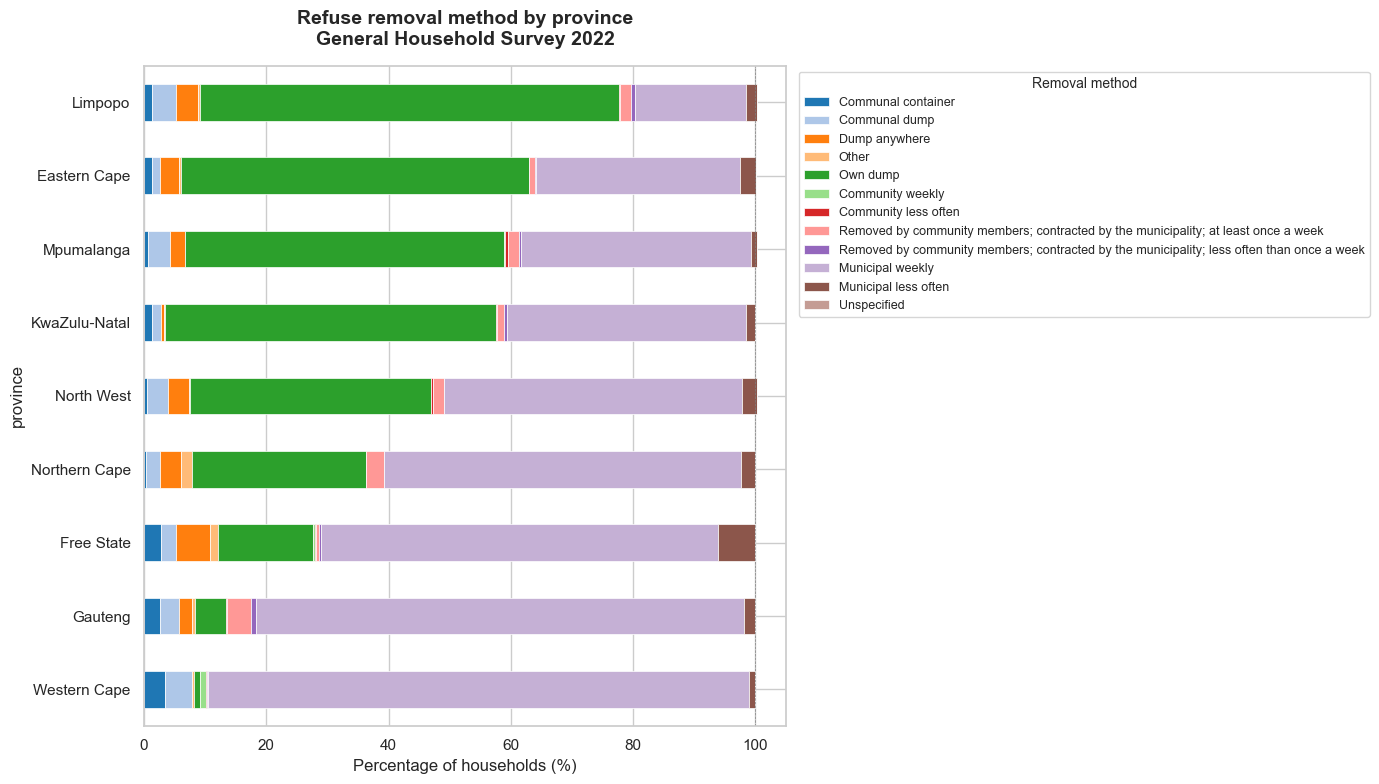

In [7]:
# ============================================
# CHART 2 — Full refuse removal composition
# by province (stacked bar)
# ============================================

# Step 1 — Calculate percentage of each category per province
province_totals = refuse_removal.groupby('province')['count'].sum()

refuse_pct = refuse_removal.copy()
refuse_pct['percentage'] = (
    refuse_pct['count'] / 
    refuse_pct['province'].map(province_totals) * 100
).round(1)

# Step 2 — Pivot to wide format for stacked bar
# Rows = provinces, Columns = refuse categories, Values = percentage
refuse_wide = refuse_pct.pivot_table(
    index='province',
    columns='refuse_type',
    values='percentage',
    fill_value=0
)

# Step 3 — Shorten category names for the legend
short_names = {
    'Removed by local authority/private company at least once a week': 
        'Municipal weekly',
    'Removed by local authority/private company less often than once a week': 
        'Municipal less often',
    'Removed by community members; contracted by the local authority/private company at least once a week': 
        'Community contracted weekly',
    'Removed by community members; contracted by the local authority/private company less often than once a week': 
        'Community contracted less often',
    'Removed by community members at least once a week': 
        'Community weekly',
    'Removed by community members less often than once a week': 
        'Community less often',
    'Communal refuse dump': 
        'Communal dump',
    'Communal container/central collection point': 
        'Communal container',
    'Own refuse dump': 
        'Own dump',
    'Dump or leave rubbish anywhere': 
        'Dump anywhere',
    'Other': 'Other',
    'Unspecified': 'Unspecified'
}

refuse_wide.columns = [
    short_names.get(col, col) for col in refuse_wide.columns
]

# Step 4 — Sort provinces by municipal weekly (same order as chart 1)
refuse_wide = refuse_wide.reindex(
    weekly_removal.sort_values('percentage', ascending=False)['province'].values
)

# Step 5 — Build the chart
fig, ax = plt.subplots(figsize=(14, 8))

colors = sns.color_palette('tab20', len(refuse_wide.columns))

refuse_wide.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Percentage of households (%)', fontsize=12)
ax.set_title(
    'Refuse removal method by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlim(0, 105)
ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9,
    title='Removal method',
    title_fontsize=10
)
ax.axvline(100, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/chart02_refuse_composition.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Quick look at refuse_irregular
print(refuse_irregular['refuse_irregular'].unique())
print(f"\nShape: {refuse_irregular.shape}")
print(f"\nSample:")
print(refuse_irregular.head(12))

<StringArray>
['Yes', 'No', 'Unspecified']
Length: 3, dtype: str

Shape: (27, 3)

Sample:
         province refuse_irregular    count
0    Western Cape              Yes   597270
1    Western Cape               No  6633588
2    Western Cape      Unspecified        0
3    Eastern Cape              Yes  2044036
4    Eastern Cape               No  4495019
5    Eastern Cape      Unspecified        0
6   Northern Cape              Yes   464635
7   Northern Cape               No   829409
8   Northern Cape      Unspecified        0
9      Free State              Yes  1762047
10     Free State               No  1238391
11     Free State      Unspecified        0


Correlation table:
     province  irregular_pct  municipal_weekly_pct  own_dump_pct  dump_anywhere_pct
   Free State           58.7                  64.9          15.5                5.6
   Mpumalanga           54.1                  37.6          52.1                2.5
Northern Cape           35.9                  58.5          28.4                3.5
 Eastern Cape           31.3                  33.4          56.9                3.1
   North West           30.6                  48.7          39.4                3.3
KwaZulu-Natal           21.2                  39.1          54.0                0.5
      Gauteng           13.0                  79.7           5.2                2.0
      Limpopo           12.2                  18.2          68.6                3.7
 Western Cape            8.3                  88.5           1.0                0.1


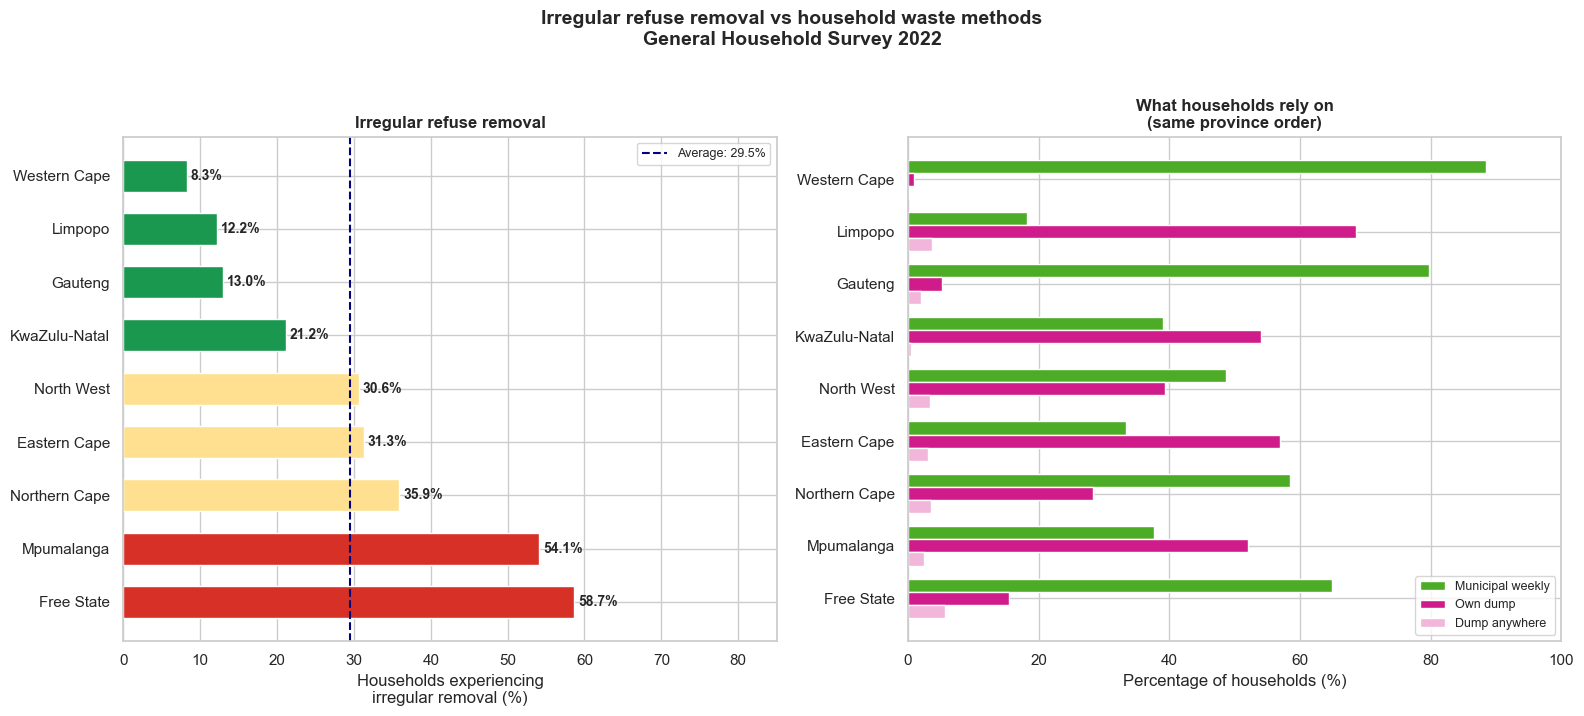

In [9]:
# ============================================
# CHART 3 — Irregular removal vs composition
# ============================================

# Step 1 — Calculate irregular removal percentage per province
province_totals_irr = refuse_irregular.groupby(
    'province')['count'].sum()

irregular_pct = refuse_irregular.copy()
irregular_pct['percentage'] = (
    irregular_pct['count'] /
    irregular_pct['province'].map(province_totals_irr) * 100
).round(1)

# Get just the Yes percentage per province
irregular_yes = irregular_pct[
    irregular_pct['refuse_irregular'] == 'Yes'
][['province', 'percentage', 'count']].copy()

irregular_yes = irregular_yes.rename(
    columns={'percentage': 'irregular_pct'})

# Step 2 — Get own dump and dump anywhere percentages
# from our earlier refuse_pct DataFrame
own_dump = refuse_pct[
    refuse_pct['refuse_type'] == 'Own refuse dump'
][['province', 'percentage']].rename(
    columns={'percentage': 'own_dump_pct'})

dump_anywhere = refuse_pct[
    refuse_pct['refuse_type'] == 'Dump or leave rubbish anywhere'
][['province', 'percentage']].rename(
    columns={'percentage': 'dump_anywhere_pct'})

municipal_weekly = refuse_pct[
    refuse_pct['refuse_type'] == 
    'Removed by local authority/private company at least once a week'
][['province', 'percentage']].rename(
    columns={'percentage': 'municipal_weekly_pct'})

# Step 3 — Merge everything together
correlation_df = irregular_yes.merge(own_dump, on='province')
correlation_df = correlation_df.merge(dump_anywhere, on='province')
correlation_df = correlation_df.merge(municipal_weekly, on='province')

# Sort by irregular percentage
correlation_df = correlation_df.sort_values(
    'irregular_pct', ascending=False)

print("Correlation table:")
print(correlation_df[[
    'province', 
    'irregular_pct', 
    'municipal_weekly_pct',
    'own_dump_pct', 
    'dump_anywhere_pct'
]].to_string(index=False))

# Step 4 — Build grouped comparison chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left chart — irregular removal percentage by province
colors_irr = ['#d73027' if x > 50 else '#fee090' 
               if x > 25 else '#1a9850' 
               for x in correlation_df['irregular_pct']]

axes[0].barh(
    correlation_df['province'],
    correlation_df['irregular_pct'],
    color=colors_irr,
    edgecolor='white',
    height=0.6
)

for i, (val, prov) in enumerate(zip(
    correlation_df['irregular_pct'], 
    correlation_df['province']
)):
    axes[0].text(
        val + 0.5, i, f'{val}%',
        va='center', fontsize=10, fontweight='bold'
    )

axes[0].set_xlabel('Households experiencing\nirregular removal (%)')
axes[0].set_title('Irregular refuse removal', fontweight='bold')
axes[0].set_xlim(0, 85)
axes[0].axvline(
    correlation_df['irregular_pct'].mean(),
    color='navy', linestyle='--', linewidth=1.5,
    label=f'Average: {correlation_df["irregular_pct"].mean():.1f}%'
)
axes[0].legend(fontsize=9)

# Right chart — what those households rely on instead
bar_width = 0.25
provinces = correlation_df['province'].values
x = range(len(provinces))

bars1 = axes[1].barh(
    [i + bar_width for i in x],
    correlation_df['municipal_weekly_pct'],
    height=bar_width,
    color='#4dac26',
    label='Municipal weekly'
)
bars2 = axes[1].barh(
    x,
    correlation_df['own_dump_pct'],
    height=bar_width,
    color='#d01c8b',
    label='Own dump'
)
bars3 = axes[1].barh(
    [i - bar_width for i in x],
    correlation_df['dump_anywhere_pct'],
    height=bar_width,
    color='#f1b6da',
    label='Dump anywhere'
)

axes[1].set_yticks(list(x))
axes[1].set_yticklabels(provinces)
axes[1].set_xlabel('Percentage of households (%)')
axes[1].set_title(
    'What households rely on\n(same province order)',
    fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 100)

fig.suptitle(
    'Irregular refuse removal vs household waste methods\n'
    'General Household Survey 2022',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart03_refuse_irregular_correlation.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

## Analytical note — Irregular removal limitation

The irregular removal variable measures reliability of existing 
service not service quality. Provinces like Limpopo show low 
irregular removal not because municipal service is reliable but 
because most households might have no municipal service to be irregular 
about — they self manage waste consistently via own dumps.

This variable should always be read alongside refuse composition 
data to avoid misinterpretation.

In [10]:
# Save correlation table to outputs for reference
correlation_df.to_csv(
    '../outputs/refuse_correlation_table.csv', 
    index=False
)
print("Correlation table saved.")

Correlation table saved.


In [11]:
# ============================================
# CHART 4 — Littering prevalence and 
# correlation with refuse disposal methods
# ============================================

# Step 1 — Calculate littering Yes percentage per province
littering = pd.read_csv(
    '../data/cleaned/GHS2022_littering_cleaned.csv')

province_totals_lit = littering.groupby(
    'province')['count'].sum()

littering_pct = littering.copy()
littering_pct['percentage'] = (
    littering_pct['count'] /
    littering_pct['province'].map(province_totals_lit) * 100
).round(1)

littering_yes = littering_pct[
    littering_pct['littering'] == 'Yes'
][['province', 'percentage']].rename(
    columns={'percentage': 'littering_pct'})

# Step 2 — Merge with our existing correlation table
full_correlation = correlation_df.merge(
    littering_yes, on='province')

full_correlation = full_correlation.sort_values(
    'littering_pct', ascending=False)

print("Full correlation table:")
print(full_correlation[[
    'province',
    'littering_pct',
    'irregular_pct',
    'own_dump_pct',
    'dump_anywhere_pct',
    'municipal_weekly_pct'
]].to_string(index=False))

Full correlation table:
     province  littering_pct  irregular_pct  own_dump_pct  dump_anywhere_pct  municipal_weekly_pct
   Free State           55.9           58.7          15.5                5.6                  64.9
   Mpumalanga           47.8           54.1          52.1                2.5                  37.6
Northern Cape           45.3           35.9          28.4                3.5                  58.5
 Eastern Cape           40.9           31.3          56.9                3.1                  33.4
   North West           31.6           30.6          39.4                3.3                  48.7
KwaZulu-Natal           30.1           21.2          54.0                0.5                  39.1
      Gauteng           28.0           13.0           5.2                2.0                  79.7
 Western Cape           26.3            8.3           1.0                0.1                  88.5
      Limpopo           24.9           12.2          68.6                3.7         

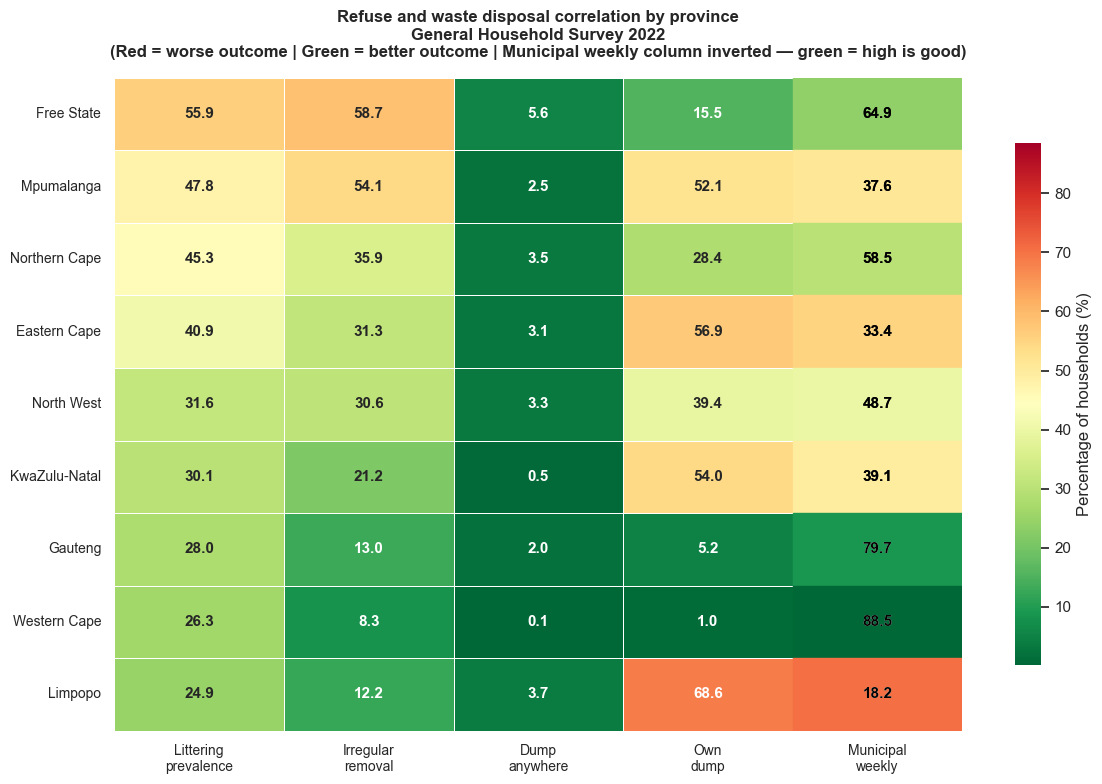


Key findings:
Highest littering: Free State at 55.9%
Lowest littering: Limpopo at 24.9%

Correlation between littering and irregular removal:
  0.951

Correlation between littering and own dump:
  -0.038

Correlation between littering and municipal weekly:
  -0.027


In [12]:
# ============================================
# CHART 4 — Full refuse correlation heatmap
# ============================================

import matplotlib.colors as mcolors

# Prepare the heatmap data
heatmap_data = full_correlation.set_index('province')[[
    'littering_pct',
    'irregular_pct', 
    'dump_anywhere_pct',
    'own_dump_pct',
    'municipal_weekly_pct'
]].copy()

# Rename columns for display
heatmap_data.columns = [
    'Littering\nprevalence',
    'Irregular\nremoval',
    'Dump\nanywhere',
    'Own\ndump',
    'Municipal\nweekly'
]

# For municipal weekly flip the colour interpretation
# high municipal weekly is GOOD so we invert it
# We do this by creating a display version
heatmap_display = heatmap_data.copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Create custom colormap — red is bad, green is good
# For municipal weekly we will annotate differently
cmap = sns.diverging_palette(10, 130, as_cmap=True)

sns.heatmap(
    heatmap_display,
    ax=ax,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'label': 'Percentage of households (%)',
        'shrink': 0.8
    },
    annot_kws={'size': 11, 'weight': 'bold'}
)

# Invert municipal weekly column colour
# by overlaying with reversed colormap
col_idx = list(heatmap_display.columns).index('Municipal\nweekly')
col_data = heatmap_display['Municipal\nweekly'].values

# Normalise for colour mapping
norm = mcolors.Normalize(
    vmin=heatmap_display.values.min(),
    vmax=heatmap_display.values.max()
)
cmap_good = plt.cm.RdYlGn

for row_idx, val in enumerate(col_data):
    color = cmap_good(norm(val))
    ax.add_patch(plt.Rectangle(
        (col_idx, row_idx), 1, 1,
        fill=True,
        color=color,
        zorder=2
    ))
    ax.text(
        col_idx + 0.5,
        row_idx + 0.5,
        f'{val:.1f}',
        ha='center', va='center',
        fontsize=11, fontweight='bold',
        color='black',
        zorder=3
    )

ax.set_title(
    'Refuse and waste disposal correlation by province\n'
    'General Household Survey 2022\n'
    '(Red = worse outcome | Green = better outcome | '
    'Municipal weekly column inverted — green = high is good)',
    fontsize=12,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10, rotation=0)

plt.tight_layout()
plt.savefig(
    '../outputs/chart04_refuse_full_correlation.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("\nKey findings:")
print(f"Highest littering: "
      f"{full_correlation.loc[full_correlation['littering_pct'].idxmax(), 'province']}"
      f" at {full_correlation['littering_pct'].max()}%")
print(f"Lowest littering: "
      f"{full_correlation.loc[full_correlation['littering_pct'].idxmin(), 'province']}"
      f" at {full_correlation['littering_pct'].min()}%")
print(f"\nCorrelation between littering and irregular removal:")
print(f"  {full_correlation[['littering_pct', 'irregular_pct']].corr().iloc[0,1]:.3f}")
print(f"\nCorrelation between littering and own dump:")
print(f"  {full_correlation[['littering_pct', 'own_dump_pct']].corr().iloc[0,1]:.3f}")
print(f"\nCorrelation between littering and municipal weekly:")
print(f"  {full_correlation[['littering_pct', 'municipal_weekly_pct']].corr().iloc[0,1]:.3f}")

## Analytical note — Provincial averages mask internal inequality

Gauteng scores well on provincial averages but field observation 
suggests significant internal variation between affluent suburbs 
and township areas. Provincial level data flattens this inequality.

Municipal level analysis in Phase 2 will provide finer resolution.
Reference bias in self-reported littering data likely understates 
actual environmental conditions in normalised informal settlements.

## Key Finding — Refuse Analysis

**Strongest predictor of littering: Irregular removal (r = 0.951)**

Irregular removal of existing municipal services is a near-perfect 
predictor of household littering perception across SA provinces.
Own dump usage (r = -0.038) and municipal weekly coverage 
(r = -0.027) show no meaningful correlation with littering.

Implication: Service reliability matters more than service presence.
A municipality that collects inconsistently causes more environmental 
damage than one that never collected at all — because households 
that relied on the service have no alternative system in place 
when it fails.

This finding will inform the DES score weighting in Phase 2.

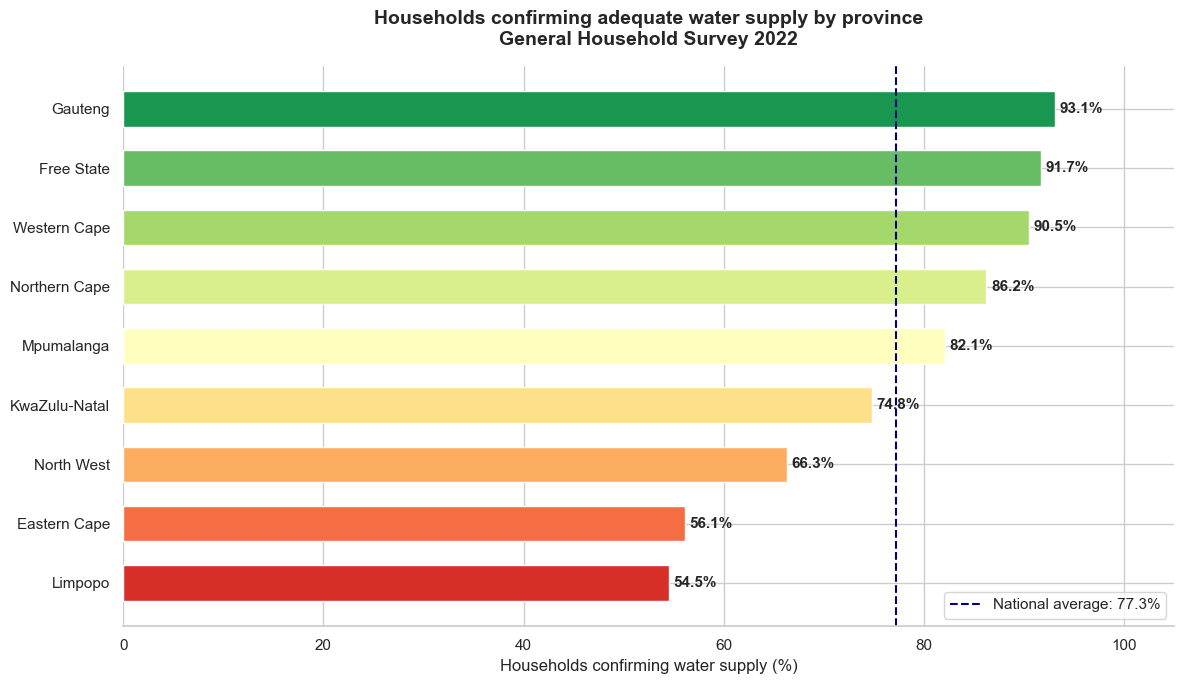


Data:
     province    count  percentage
      Gauteng 15149588        93.1
   Free State  2750738        91.7
 Western Cape  6547368        90.5
Northern Cape  1115343        86.2
   Mpumalanga  3986595        82.1
KwaZulu-Natal  8840016        74.8
   North West  2787323        66.3
 Eastern Cape  3665758        56.1
      Limpopo  3360251        54.5


In [13]:
# ============================================
# CHART 5 — Water supply availability
# by province
# ============================================

# Step 1 — Calculate Yes percentage per province
province_totals_ws = water_supply.groupby(
    'province')['count'].sum()

water_supply_pct = water_supply.copy()
water_supply_pct['percentage'] = (
    water_supply_pct['count'] /
    water_supply_pct['province'].map(province_totals_ws) * 100
).round(1)

# Get Yes percentage only
supply_yes = water_supply_pct[
    water_supply_pct['water_supply'] == 'Yes'
][['province', 'percentage', 'count']].copy()

supply_yes = supply_yes.sort_values(
    'percentage', ascending=True)

# Step 2 — Build chart
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    supply_yes['province'],
    supply_yes['percentage'],
    color=sns.color_palette('RdYlGn', len(supply_yes)),
    edgecolor='white',
    height=0.6
)

for bar, pct in zip(bars, supply_yes['percentage']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

national_avg = supply_yes['percentage'].mean()
ax.axvline(
    national_avg,
    color='navy',
    linestyle='--',
    linewidth=1.5,
    label=f'National average: {national_avg:.1f}%'
)

ax.set_xlabel('Households confirming water supply (%)', fontsize=12)
ax.set_title(
    'Households confirming adequate water supply by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlim(0, 105)
ax.legend(fontsize=11)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.savefig(
    '../outputs/chart05_water_supply.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("\nData:")
print(supply_yes[['province', 'count', 'percentage']]
      .sort_values('percentage', ascending=False)
      .to_string(index=False))

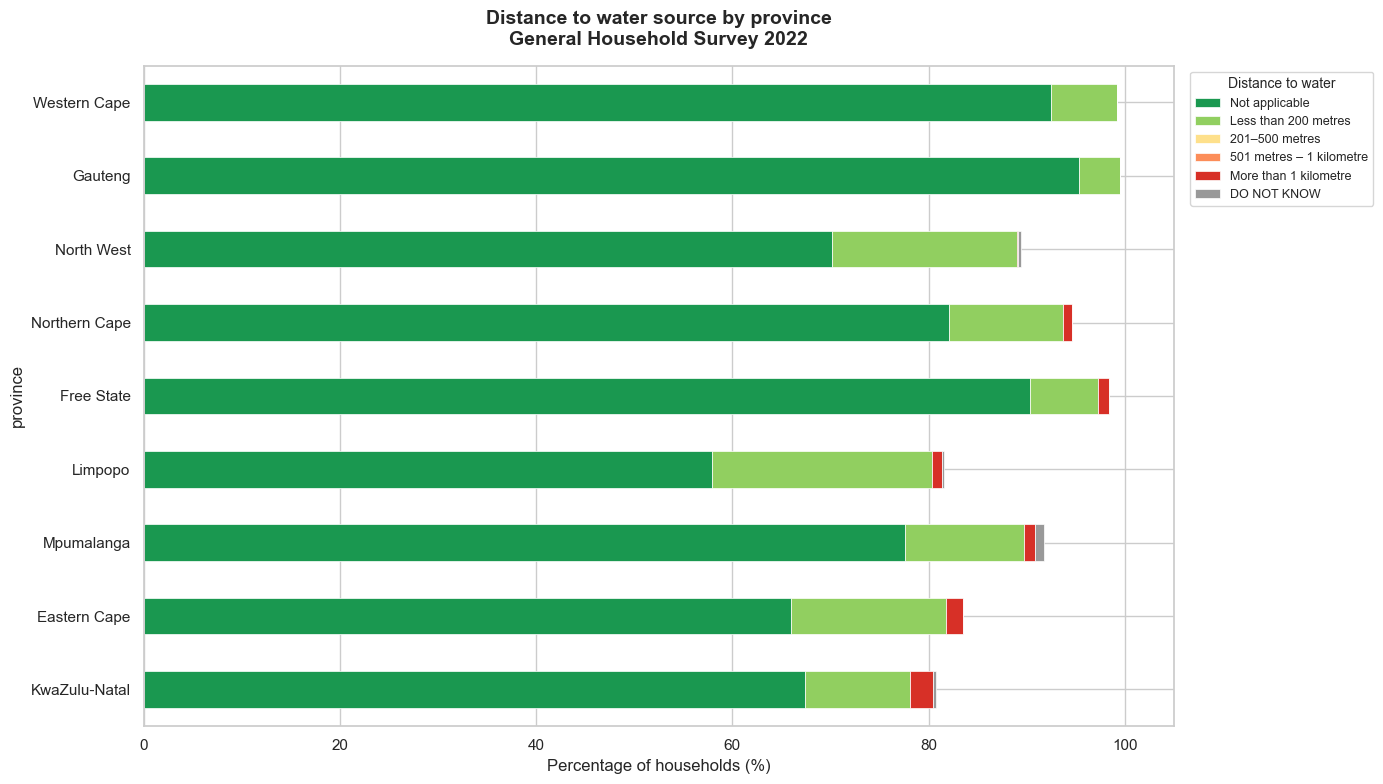


Households more than 1km from water source:
     province  percentage
KwaZulu-Natal         2.4
 Eastern Cape         1.7
   Mpumalanga         1.2
      Limpopo         1.1
   Free State         1.1
Northern Cape         0.9
   North West         0.1
 Western Cape         0.0
      Gauteng         0.0


In [14]:
# ============================================
# CHART 6 — Distance to water source
# by province
# ============================================

# Step 1 — Calculate percentage per category per province
province_totals_wd = water_distance.groupby(
    'province')['count'].sum()

water_dist_pct = water_distance.copy()
water_dist_pct['percentage'] = (
    water_dist_pct['count'] /
    water_dist_pct['province'].map(province_totals_wd) * 100
).round(1)

# Step 2 — Define distance order from closest to furthest
distance_order = [
    'Not applicable',
    'Less than 200 metres',
    '201–500 metres',
    '501 metres – 1 kilometre',
    'More than 1 kilometre',
    'DO NOT KNOW'
]

# Step 3 — Pivot to wide format
dist_wide = water_dist_pct.pivot_table(
    index='province',
    columns='water_distance',
    values='percentage',
    fill_value=0
)

# Reorder columns
dist_wide = dist_wide.reindex(columns=distance_order)

# Step 4 — Sort provinces by worst access
# More than 1 kilometre is the critical metric
dist_wide = dist_wide.sort_values(
    'More than 1 kilometre', ascending=False)

# Step 5 — Build stacked bar
fig, ax = plt.subplots(figsize=(14, 8))

colors = [
    '#1a9850',  # Not applicable - green (has water on site)
    '#91cf60',  # Less than 200m - light green
    '#fee08b',  # 201-500m - yellow
    '#fc8d59',  # 501m-1km - orange
    '#d73027',  # More than 1km - red
    '#999999'   # Do not know - grey
]

dist_wide.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Percentage of households (%)', fontsize=12)
ax.set_title(
    'Distance to water source by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlim(0, 105)
ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9,
    title='Distance to water',
    title_fontsize=10
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart06_water_distance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Print the critical metric — more than 1km
print("\nHouseholds more than 1km from water source:")
far_water = water_dist_pct[
    water_dist_pct['water_distance'] == 'More than 1 kilometre'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(far_water.to_string(index=False))

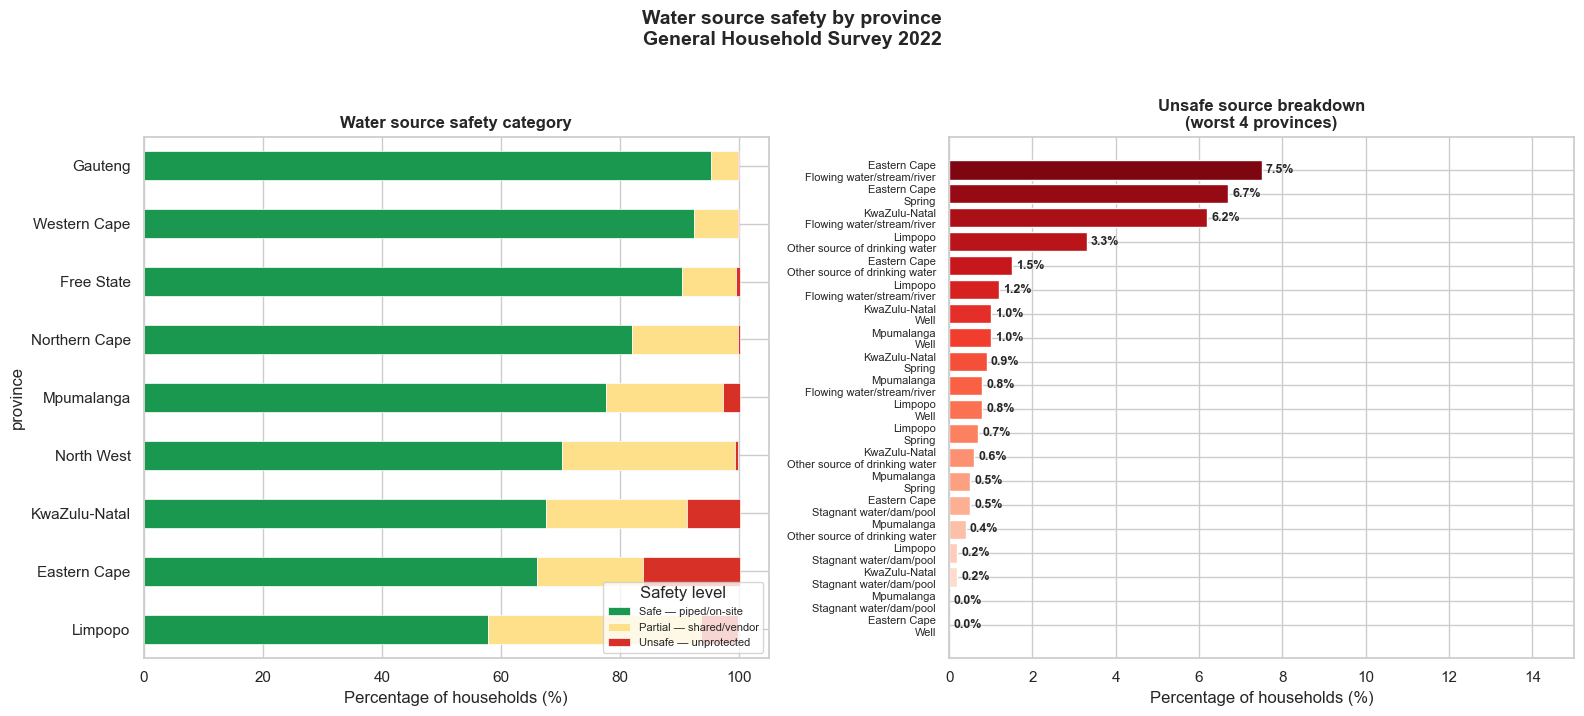


Unsafe water source percentage by province:
     province  percentage
 Eastern Cape        16.2
KwaZulu-Natal         8.9
      Limpopo         6.2
   Mpumalanga         2.7
   Free State         0.6
   North West         0.4
Northern Cape         0.3
      Gauteng         0.1
 Western Cape         0.1


In [15]:
# ============================================
# CHART 7 — Water source composition
# by province
# ============================================

# Step 1 — Calculate percentage per source per province
province_totals_wsrc = water_source.groupby(
    'province')['count'].sum()

water_src_pct = water_source.copy()
water_src_pct['percentage'] = (
    water_src_pct['count'] /
    water_src_pct['province'].map(province_totals_wsrc) * 100
).round(1)

# Step 2 — Categorise sources into safe vs unsafe
# This is the key analytical decision
safe_sources = [
    'Piped (tap) water in dwelling',
    'Piped (tap) water on site or in yard',
    'Borehole on site',
    'Rain-water tank on site'
]

partial_sources = [
    'Neighbour\'s tap',
    'Public/communal tap',
    'Borehole outside yard',
    'Water-carrier/tanker',
    'Water vendor'
]

unsafe_sources = [
    'Flowing water/stream/river',
    'Stagnant water/dam/pool',
    'Well',
    'Spring',
    'Other source of drinking water'
]

# Add safety category to dataframe
def categorise_source(source):
    if source in safe_sources:
        return 'Safe — piped/on-site'
    elif source in partial_sources:
        return 'Partial — shared/vendor'
    else:
        return 'Unsafe — unprotected'

water_src_pct['safety_category'] = water_src_pct[
    'water_source'].apply(categorise_source)

# Step 3 — Aggregate by safety category per province
safety_agg = water_src_pct.groupby(
    ['province', 'safety_category']
)['percentage'].sum().reset_index()

# Pivot
safety_wide = safety_agg.pivot_table(
    index='province',
    columns='safety_category',
    values='percentage',
    fill_value=0
)

# Reorder columns
col_order = [
    'Safe — piped/on-site',
    'Partial — shared/vendor',
    'Unsafe — unprotected'
]
safety_wide = safety_wide.reindex(columns=col_order)

# Sort by safe percentage descending
safety_wide = safety_wide.sort_values(
    'Safe — piped/on-site', ascending=True)

# Step 4 — Build chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — safety category stacked bar
colors_safety = ['#1a9850', '#fee08b', '#d73027']

safety_wide.plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=colors_safety,
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_xlabel('Percentage of households (%)')
axes[0].set_title(
    'Water source safety category',
    fontweight='bold'
)
axes[0].set_xlim(0, 105)
axes[0].legend(
    loc='lower right',
    fontsize=8,
    title='Safety level'
)

# Right — unsafe sources breakdown for bottom 4 provinces
bottom_4 = safety_wide.sort_values(
    'Unsafe — unprotected',
    ascending=False
).head(4).index.tolist()

unsafe_detail = water_src_pct[
    (water_src_pct['province'].isin(bottom_4)) &
    (water_src_pct['safety_category'] == 'Unsafe — unprotected')
].sort_values('percentage', ascending=True)

colors_unsafe = sns.color_palette(
    'Reds', len(unsafe_detail))

bars = axes[1].barh(
    range(len(unsafe_detail)),
    unsafe_detail['percentage'],
    color=colors_unsafe,
    edgecolor='white'
)

axes[1].set_yticks(range(len(unsafe_detail)))
axes[1].set_yticklabels([
    f"{row['province']}\n{row['water_source']}"
    for _, row in unsafe_detail.iterrows()
], fontsize=8)

for bar, pct in zip(bars, unsafe_detail['percentage']):
    axes[1].text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

axes[1].set_xlabel('Percentage of households (%)')
axes[1].set_title(
    'Unsafe source breakdown\n(worst 4 provinces)',
    fontweight='bold'
)
axes[1].set_xlim(0, 15)

fig.suptitle(
    'Water source safety by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart07_water_source_safety.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Print unsafe percentages
print("\nUnsafe water source percentage by province:")
unsafe_summary = safety_agg[
    safety_agg['safety_category'] == 'Unsafe — unprotected'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(unsafe_summary.to_string(index=False))

## Key Finding — Water Analysis

**Eastern Cape water crisis is quantified: 16.2% unsafe sources**

Eastern Cape leads all provinces with 16.2% of households using 
unprotected water sources (rivers, springs, stagnant water).
KwaZulu-Natal second at 8.9%.

Distance to water is NOT the primary inequality metric — most 
households have water within 200 metres. Source safety and supply 
reliability are the critical dimensions.

Piped water categorised as 'safe' may still be unreliable or 
contaminated in municipalities with failing treatment infrastructure.
This analysis measures source type not water quality — an important 
limitation for the DES score methodology.

Combined Eastern Cape and KZN unsafe water households: 
approximately 2 million people on unprotected sources in 2022.

In [16]:
safe_sanitation = [
    'Flush toilet connected to a public sewerage system',
    'Flush toilet connected to a septic tank or conservancy tank',
    'Pour bucket-flush toilet connected to a septic tank (or septic pit)'
]

inadequate_sanitation = [
    'Pit latrine/toilet with ventilation pipe',
    'Pit latrine/toilet without ventilation pipe',
    'Bucket toilet',
    'Portable flush toilet',
    'Composting toilet',
    'Urine diversion dry toilet',
    'Chemical toilet'
]

no_sanitation = [
    'Open defecation (e.g. no facilities; field; bush)'
]

other_sanitation = [
    'Other toilet facility',
    'Unspecified'
]

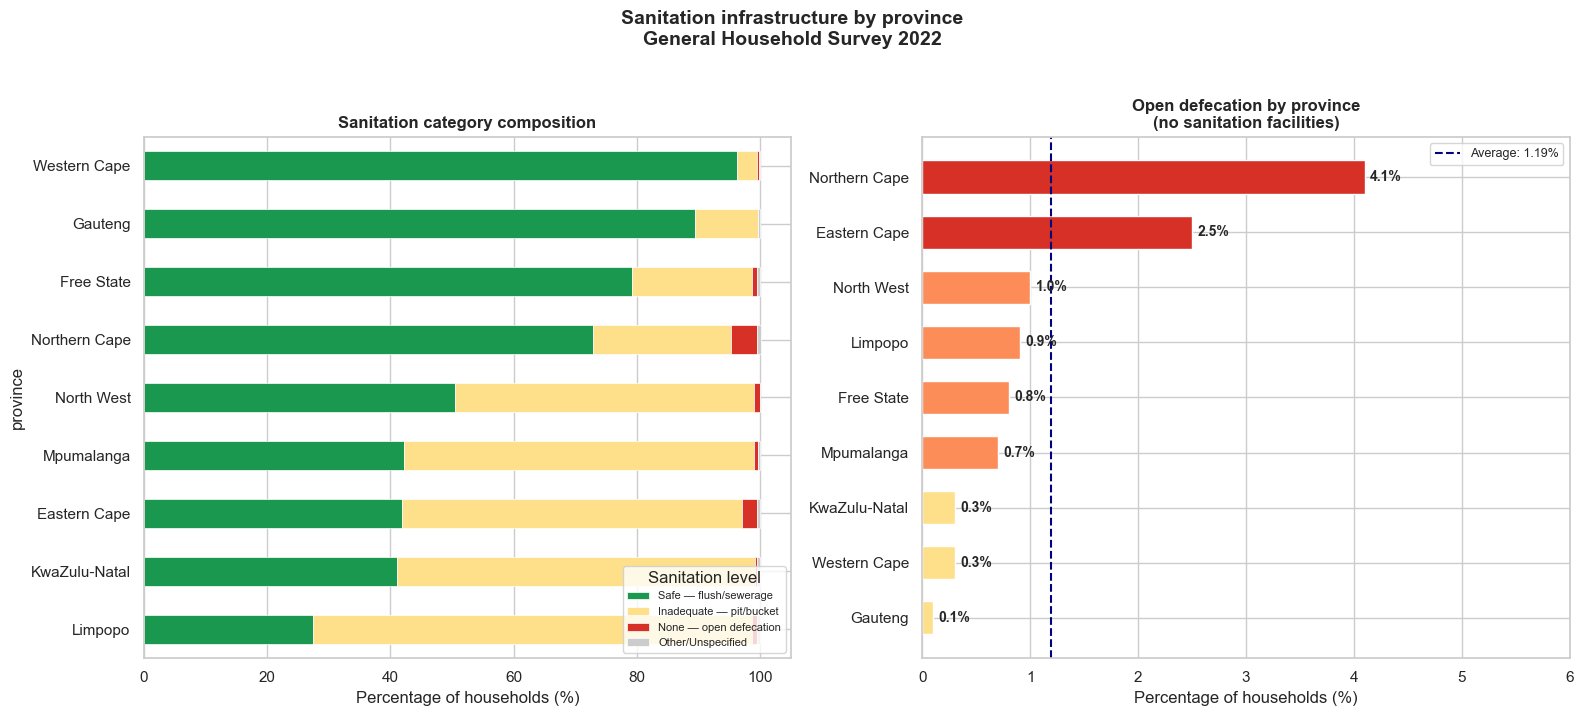


Safe sanitation percentage by province:
     province  percentage
 Western Cape        96.2
      Gauteng        89.4
   Free State        79.2
Northern Cape        72.9
   North West        50.5
   Mpumalanga        42.2
 Eastern Cape        41.9
KwaZulu-Natal        41.1
      Limpopo        27.4

Open defecation percentage by province:
     province  percentage  count
Northern Cape         4.1  52480
 Eastern Cape         2.5 163785
   North West         1.0  40746
      Limpopo         0.9  57783
   Free State         0.8  23771
   Mpumalanga         0.7  33311
 Western Cape         0.3  25052
KwaZulu-Natal         0.3  40290
      Gauteng         0.1   9523


In [17]:
# ============================================
# CHART 8 — Sanitation safety by province
# ============================================

# Step 1 — Calculate percentage per type per province
province_totals_tt = toilet_type.groupby(
    'province')['count'].sum()

toilet_pct = toilet_type.copy()
toilet_pct['percentage'] = (
    toilet_pct['count'] /
    toilet_pct['province'].map(province_totals_tt) * 100
).round(1)

# Step 2 — Categorise
def categorise_toilet(toilet):
    if toilet in safe_sanitation:
        return 'Safe — flush/sewerage'
    elif toilet in inadequate_sanitation:
        return 'Inadequate — pit/bucket'
    elif toilet in no_sanitation:
        return 'None — open defecation'
    else:
        return 'Other/Unspecified'

toilet_pct['sanitation_category'] = toilet_pct[
    'toilet_type'].apply(categorise_toilet)

# Step 3 — Aggregate by category per province
sanitation_agg = toilet_pct.groupby(
    ['province', 'sanitation_category']
)['percentage'].sum().reset_index()

# Pivot
sanitation_wide = sanitation_agg.pivot_table(
    index='province',
    columns='sanitation_category',
    values='percentage',
    fill_value=0
)

# Reorder columns
col_order = [
    'Safe — flush/sewerage',
    'Inadequate — pit/bucket',
    'None — open defecation',
    'Other/Unspecified'
]
sanitation_wide = sanitation_wide.reindex(
    columns=col_order)

# Sort by safe percentage descending
sanitation_wide = sanitation_wide.sort_values(
    'Safe — flush/sewerage', ascending=True)

# Step 4 — Build chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — stacked bar composition
colors_san = ['#1a9850', '#fee08b', '#d73027', '#cccccc']

sanitation_wide.plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=colors_san,
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_xlabel('Percentage of households (%)')
axes[0].set_title(
    'Sanitation category composition',
    fontweight='bold'
)
axes[0].set_xlim(0, 105)
axes[0].legend(
    loc='lower right',
    fontsize=8,
    title='Sanitation level'
)

# Right — open defecation detail
open_defecation = toilet_pct[
    toilet_pct['toilet_type'] == 
    'Open defecation (e.g. no facilities; field; bush)'
][['province', 'percentage', 'count']].sort_values(
    'percentage', ascending=True)

colors_od = ['#d73027' if x > 1 else '#fc8d59' 
             if x > 0.5 else '#fee08b'
             for x in open_defecation['percentage']]

bars = axes[1].barh(
    open_defecation['province'],
    open_defecation['percentage'],
    color=colors_od,
    edgecolor='white',
    height=0.6
)

for bar, pct in zip(bars, open_defecation['percentage']):
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

axes[1].axvline(
    open_defecation['percentage'].mean(),
    color='navy',
    linestyle='--',
    linewidth=1.5,
    label=f'Average: '
          f'{open_defecation["percentage"].mean():.2f}%'
)
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Percentage of households (%)')
axes[1].set_title(
    'Open defecation by province\n(no sanitation facilities)',
    fontweight='bold'
)
axes[1].set_xlim(0, 6)

fig.suptitle(
    'Sanitation infrastructure by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart08_sanitation.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Print key numbers
print("\nSafe sanitation percentage by province:")
safe_san = sanitation_agg[
    sanitation_agg['sanitation_category'] == 
    'Safe — flush/sewerage'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(safe_san.to_string(index=False))

print("\nOpen defecation percentage by province:")
print(open_defecation[['province', 'percentage', 'count']]
      .sort_values('percentage', ascending=False)
      .to_string(index=False))

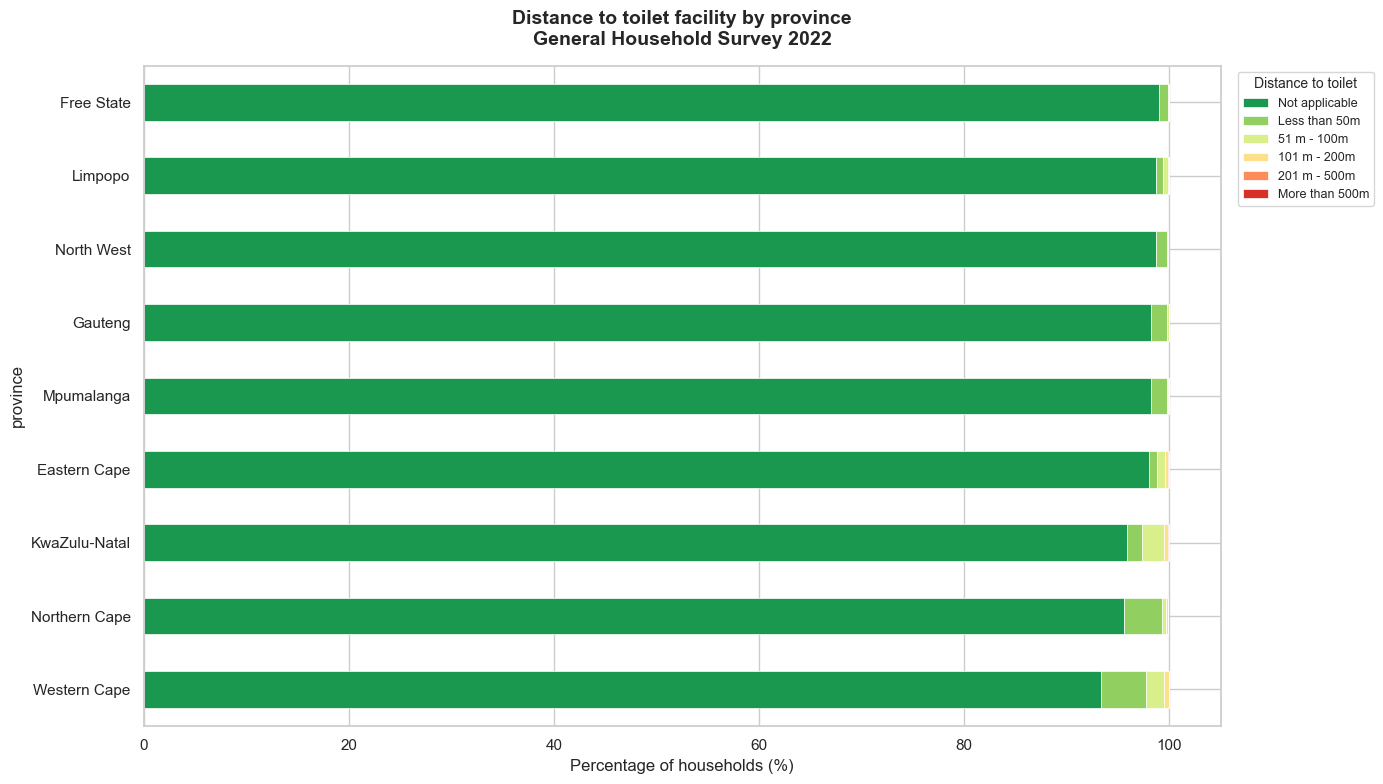


Households more than 500m from toilet:
     province  percentage  count
 Western Cape         0.0      0
 Eastern Cape         0.0      0
Northern Cape         0.0    505
   Free State         0.0      0
KwaZulu-Natal         0.0      0
   North West         0.0      0
      Gauteng         0.0      0
   Mpumalanga         0.0      0
      Limpopo         0.0      0

Households with toilet in dwelling (Not applicable):
     province  percentage
   Free State        99.0
      Limpopo        98.7
   North West        98.7
   Mpumalanga        98.2
      Gauteng        98.2
 Eastern Cape        98.0
KwaZulu-Natal        95.9
Northern Cape        95.6
 Western Cape        93.3


In [18]:
# ============================================
# CHART 9 — Toilet distance for worst provinces
# ============================================

# Step 1 — Calculate distance percentages
province_totals_td = toilet_distance.groupby(
    'province')['count'].sum()

toilet_dist_pct = toilet_distance.copy()
toilet_dist_pct['percentage'] = (
    toilet_dist_pct['count'] /
    toilet_dist_pct['province'].map(province_totals_td) * 100
).round(1)

# Step 2 — Define distance order
distance_order_toilet = [
    'Not applicable',
    'Less than 50m',
    '51 m - 100m',
    '101 m - 200m',
    '201 m - 500m',
    'More than 500m'
]

# Step 3 — Pivot
toilet_dist_wide = toilet_dist_pct.pivot_table(
    index='province',
    columns='toilet_distance',
    values='percentage',
    fill_value=0
)

toilet_dist_wide = toilet_dist_wide.reindex(
    columns=distance_order_toilet)

# Sort by not applicable descending
# Not applicable means toilet is in the dwelling
toilet_dist_wide = toilet_dist_wide.sort_values(
    'Not applicable', ascending=True)

# Step 4 — Build chart
fig, ax = plt.subplots(figsize=(14, 8))

colors_dist = [
    '#1a9850',  # Not applicable — in dwelling
    '#91cf60',  # Less than 50m
    '#d9ef8b',  # 51-100m
    '#fee08b',  # 101-200m
    '#fc8d59',  # 201-500m
    '#d73027'   # More than 500m
]

toilet_dist_wide.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=colors_dist,
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Percentage of households (%)', fontsize=12)
ax.set_title(
    'Distance to toilet facility by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlim(0, 105)
ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9,
    title='Distance to toilet',
    title_fontsize=10
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart09_toilet_distance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Print more than 500m percentage
print("\nHouseholds more than 500m from toilet:")
far_toilet = toilet_dist_pct[
    toilet_dist_pct['toilet_distance'] == 'More than 500m'
][['province', 'percentage', 'count']].sort_values(
    'percentage', ascending=False)
print(far_toilet.to_string(index=False))

# Print not applicable percentage
print("\nHouseholds with toilet in dwelling (Not applicable):")
in_dwelling = toilet_dist_pct[
    toilet_dist_pct['toilet_distance'] == 'Not applicable'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(in_dwelling.to_string(index=False))

## Key Finding — Sanitation Analysis

**Limpopo sanitation crisis confirmed across all metrics:**
- Only 27.4% safe sanitation (lowest of all provinces)
- 70% inadequate pit latrines on premises
- 0.9% open defecation — 57,783 households

**Northern Cape open defecation paradox:**
- Highest percentage at 4.1% despite small population
- Geography and isolation rather than governance failure
- Vast Karoo settlements never reached by infrastructure

**Distance is not the sanitation problem:**
- 95-99% of households have toilet on premises
- Quality of facility is the critical dimension not proximity
- A pit latrine on your property scores well on distance
  but represents inadequate sanitation

**Western Cape informal settlement pattern visible:**
- 93.3% not applicable — lowest of all provinces
- Shared communal toilets in informal settlements
  explain the distance variance from private facilities

**Cross-cutting finding confirmed:**
Eastern Cape, KZN and Limpopo underperform across
refuse, water AND sanitation consistently.
Systemic governance failure not sector specific problems.

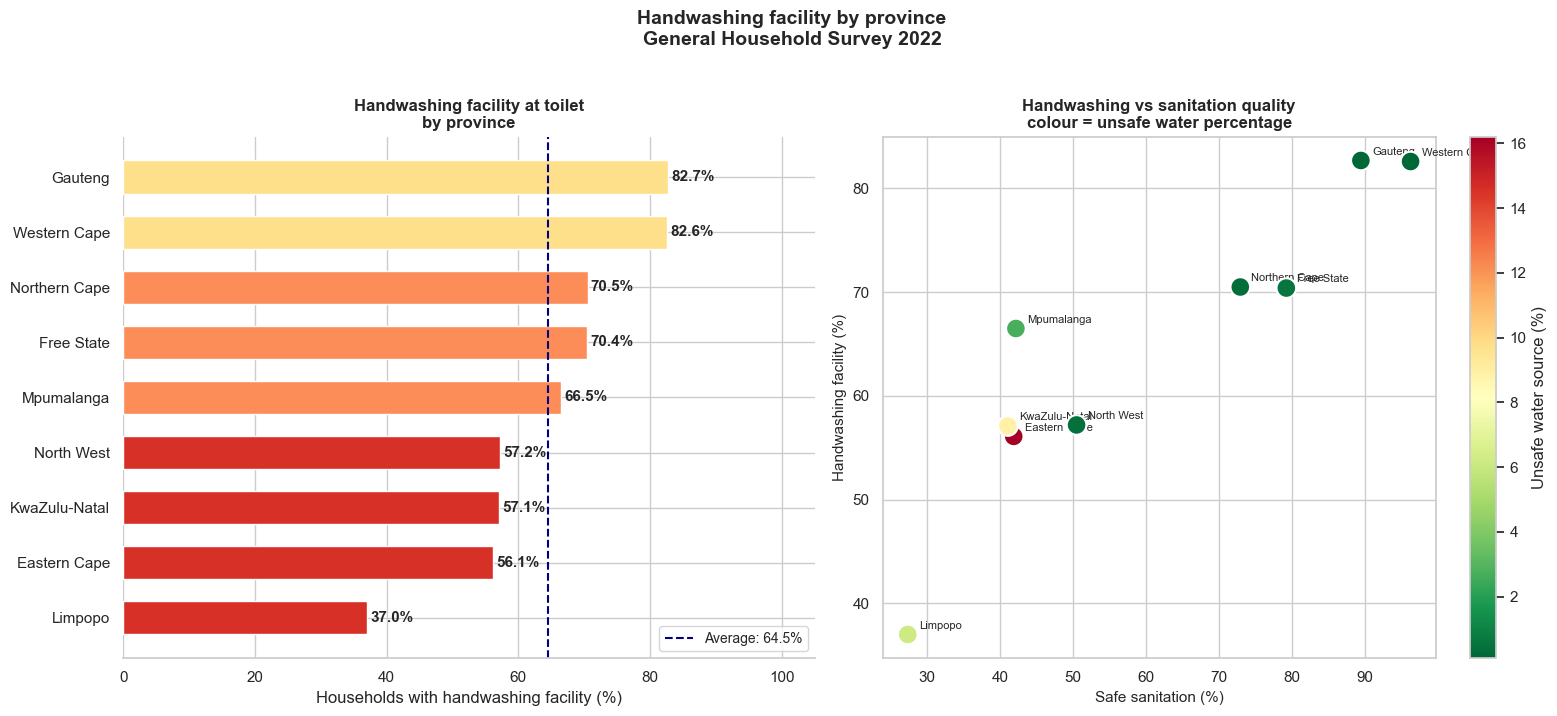


Handwashing facility percentage by province:
     province    count  percentage
      Gauteng 13435006        82.7
 Western Cape  5948933        82.6
Northern Cape   875866        70.5
   Free State  2094535        70.4
   Mpumalanga  3206749        66.5
   North West  2383711        57.2
KwaZulu-Natal  6730353        57.1
 Eastern Cape  3574739        56.1
      Limpopo  2259236        37.0

Hygiene correlation table:
     province  handwashing_pct  safe_sanitation_pct  unsafe_water_pct
      Gauteng             82.7                 89.4               0.1
 Western Cape             82.6                 96.2               0.1
Northern Cape             70.5                 72.9               0.3
   Free State             70.4                 79.2               0.6
   Mpumalanga             66.5                 42.2               2.7
   North West             57.2                 50.5               0.4
KwaZulu-Natal             57.1                 41.1               8.9
 Eastern Cape   

In [19]:
# ============================================
# CHART 10 — Handwashing facility by province
# ============================================

# Step 1 — Calculate percentages
# Exclude Not applicable (no toilet exists)
# as that is already captured in sanitation analysis
handwashing_filtered = handwashing[
    handwashing['handwashing_facility'].isin(
        ['Yes', 'No', 'Do not know'])
].copy()

province_totals_hw = handwashing_filtered.groupby(
    'province')['count'].sum()

hw_pct = handwashing_filtered.copy()
hw_pct['percentage'] = (
    hw_pct['count'] /
    hw_pct['province'].map(province_totals_hw) * 100
).round(1)

# Get Yes percentage only
hw_yes = hw_pct[
    hw_pct['handwashing_facility'] == 'Yes'
][['province', 'percentage', 'count']].copy()

hw_yes = hw_yes.sort_values('percentage', ascending=True)

# Step 2 — Build combined chart
# Left — handwashing yes percentage
# Right — correlation with unsafe water
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_hw = ['#d73027' if x < 60 else '#fc8d59'
             if x < 75 else '#fee08b'
             if x < 85 else '#91cf60'
             if x < 92 else '#1a9850'
             for x in hw_yes['percentage']]

bars = axes[0].barh(
    hw_yes['province'],
    hw_yes['percentage'],
    color=colors_hw,
    edgecolor='white',
    height=0.6
)

for bar, pct in zip(bars, hw_yes['percentage']):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

national_avg_hw = hw_yes['percentage'].mean()
axes[0].axvline(
    national_avg_hw,
    color='navy',
    linestyle='--',
    linewidth=1.5,
    label=f'Average: {national_avg_hw:.1f}%'
)
axes[0].legend(fontsize=10)
axes[0].set_xlabel('Households with handwashing facility (%)')
axes[0].set_title(
    'Handwashing facility at toilet\nby province',
    fontweight='bold'
)
axes[0].set_xlim(0, 105)
sns.despine(ax=axes[0], left=True)

# Right — scatter showing handwashing vs unsafe water correlation
# Merge handwashing yes with unsafe water percentage
unsafe_water_for_merge = safety_agg[
    safety_agg['safety_category'] == 'Unsafe — unprotected'
][['province', 'percentage']].rename(
    columns={'percentage': 'unsafe_water_pct'})

safe_san_for_merge = sanitation_agg[
    sanitation_agg['sanitation_category'] == 
    'Safe — flush/sewerage'
][['province', 'percentage']].rename(
    columns={'percentage': 'safe_sanitation_pct'})

hygiene_df = hw_yes.merge(
    unsafe_water_for_merge, on='province')
hygiene_df = hygiene_df.merge(
    safe_san_for_merge, on='province')

scatter = axes[1].scatter(
    hygiene_df['safe_sanitation_pct'],
    hygiene_df['percentage'],
    s=200,
    c=hygiene_df['unsafe_water_pct'],
    cmap='RdYlGn_r',
    edgecolors='white',
    linewidth=1.5,
    zorder=5
)

# Add province labels to scatter points
for _, row in hygiene_df.iterrows():
    axes[1].annotate(
        row['province'],
        (row['safe_sanitation_pct'], row['percentage']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8
    )

plt.colorbar(scatter, ax=axes[1],
             label='Unsafe water source (%)')

axes[1].set_xlabel('Safe sanitation (%)', fontsize=11)
axes[1].set_ylabel('Handwashing facility (%)', fontsize=11)
axes[1].set_title(
    'Handwashing vs sanitation quality\n'
    'colour = unsafe water percentage',
    fontweight='bold'
)

fig.suptitle(
    'Handwashing facility by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart10_handwashing.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("\nHandwashing facility percentage by province:")
print(hw_yes[['province', 'count', 'percentage']]
      .sort_values('percentage', ascending=False)
      .to_string(index=False))

print("\nHygiene correlation table:")
print(hygiene_df[[
    'province',
    'percentage',
    'safe_sanitation_pct',
    'unsafe_water_pct'
]].sort_values('percentage', ascending=False)
  .rename(columns={
      'percentage': 'handwashing_pct'
  }).to_string(index=False))

# Correlation
corr_san = hygiene_df[
    ['percentage', 'safe_sanitation_pct']
].corr().iloc[0, 1]
corr_water = hygiene_df[
    ['percentage', 'unsafe_water_pct']
].corr().iloc[0, 1]

print(f"\nCorrelation handwashing vs safe sanitation: {corr_san:.3f}")
print(f"Correlation handwashing vs unsafe water: {corr_water:.3f}")

## Key Finding — Handwashing and Hygiene System Analysis

**Handwashing vs safe sanitation correlation: r = 0.914**
Hygiene infrastructure functions as a system in SA.
Provinces with good sanitation almost always have
good handwashing access — the two come as a package.

**Handwashing vs unsafe water: r = -0.559**
Moderate negative relationship — unsafe water sources
are associated with lower handwashing facility access
but the relationship is less direct than sanitation.

**Limpopo hygiene crisis is complete:**
- 37.0% handwashing facility — lowest of all provinces
- 27.4% safe sanitation
- 6.2% unsafe water sources
- Consistently worst across every hygiene dimension

**Mpumalanga anomaly:**
Higher handwashing (66.5%) than safe sanitation (42.2%)
would predict — suggests independent water access points
near toilet facilities despite poor formal sanitation.

**Not applicable values in handwashing exactly match
open defecation counts from sanitation analysis —
confirming GHS survey design integrity and cross-variable
consistency of our findings.**

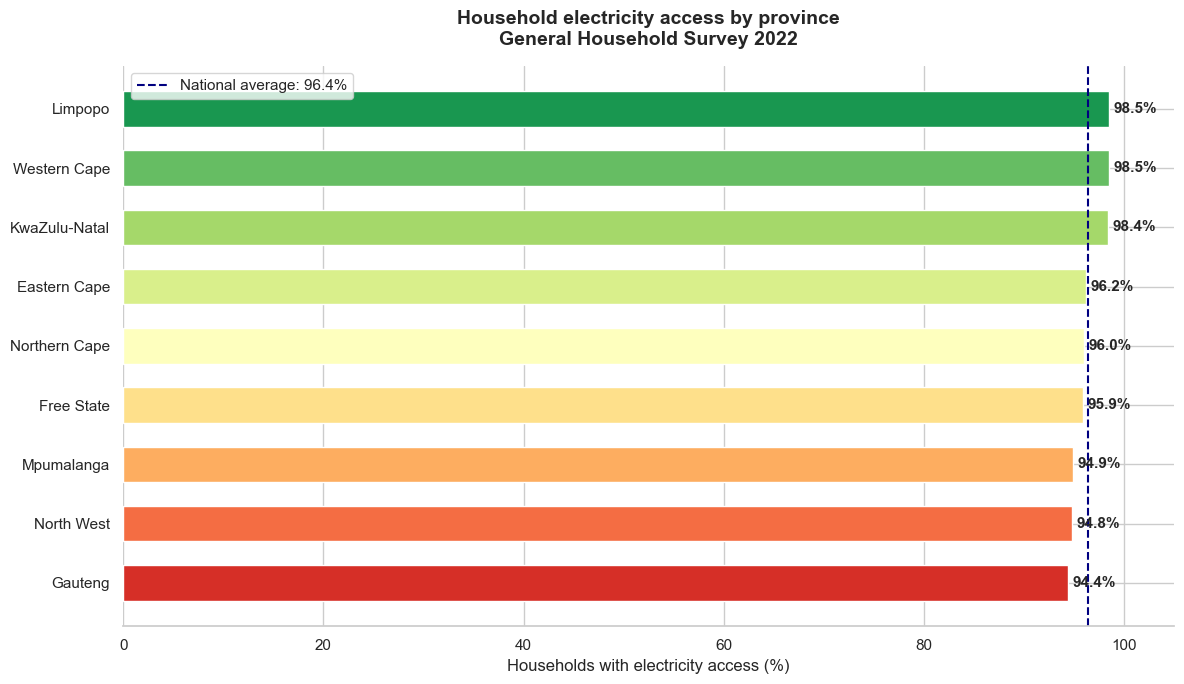


Electricity access by province:
     province    count  percentage
 Western Cape  7123512        98.5
      Limpopo  6073533        98.5
KwaZulu-Natal 11634621        98.4
 Eastern Cape  6292748        96.2
Northern Cape  1242681        96.0
   Free State  2877752        95.9
   Mpumalanga  4611515        94.9
   North West  3987861        94.8
      Gauteng 15363314        94.4


In [20]:
# ============================================
# CHART 11 — Electricity access by province
# ============================================

# Step 1 — Calculate Yes percentage per province
province_totals_ea = electricity_access.groupby(
    'province')['count'].sum()

elec_access_pct = electricity_access.copy()
elec_access_pct['percentage'] = (
    elec_access_pct['count'] /
    elec_access_pct['province'].map(province_totals_ea) * 100
).round(1)

# Get Yes only
access_yes = elec_access_pct[
    elec_access_pct['electricity_access'] == 'Yes'
][['province', 'percentage', 'count']].copy()

access_yes = access_yes.sort_values(
    'percentage', ascending=True)

# Step 2 — Build chart
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    access_yes['province'],
    access_yes['percentage'],
    color=sns.color_palette('RdYlGn', len(access_yes)),
    edgecolor='white',
    height=0.6
)

for bar, pct in zip(bars, access_yes['percentage']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

national_avg_ea = access_yes['percentage'].mean()
ax.axvline(
    national_avg_ea,
    color='navy',
    linestyle='--',
    linewidth=1.5,
    label=f'National average: {national_avg_ea:.1f}%'
)

ax.set_xlabel('Households with electricity access (%)', fontsize=12)
ax.set_title(
    'Household electricity access by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlim(0, 105)
ax.legend(fontsize=11)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.savefig(
    '../outputs/chart11_electricity_access.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("\nElectricity access by province:")
print(access_yes[['province', 'count', 'percentage']]
      .sort_values('percentage', ascending=False)
      .to_string(index=False))

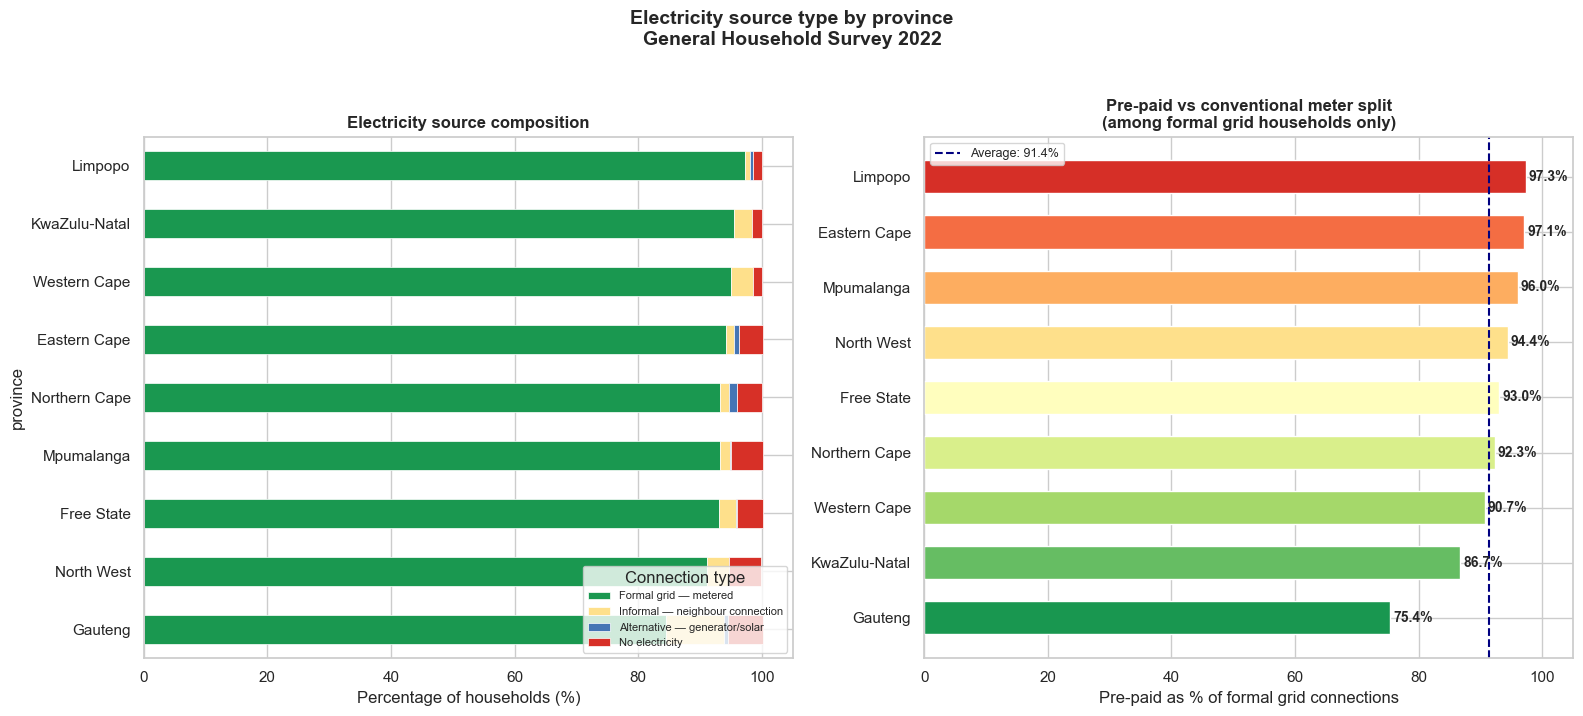


Formal grid percentage by province:
     province  percentage
      Limpopo        97.2
KwaZulu-Natal        95.5
 Western Cape        95.0
 Eastern Cape        94.2
   Mpumalanga        93.2
Northern Cape        93.2
   Free State        93.1
   North West        91.1
      Gauteng        84.5

Informal connection percentage by province:
     province  percentage
      Gauteng         9.3
   North West         3.6
 Western Cape         3.5
KwaZulu-Natal         2.9
   Free State         2.7
   Mpumalanga         1.6
Northern Cape         1.4
 Eastern Cape         1.2
      Limpopo         0.9

Alternative source percentage by province:
     province  percentage
Northern Cape         1.4
 Eastern Cape         0.9
      Gauteng         0.7
      Limpopo         0.4
   Free State         0.2
   Mpumalanga         0.2
KwaZulu-Natal         0.0
   North West         0.0
 Western Cape         0.0

Pre-paid ratio among formal grid:
     province  prepaid_pct  conventional_pct  prepaid_ratio

In [21]:
# ============================================
# CHART 12 — Electricity source composition
# by province
# ============================================

# Step 1 — Calculate percentage per source per province
province_totals_es = electricity_source.groupby(
    'province')['count'].sum()

elec_src_pct = electricity_source.copy()
elec_src_pct['percentage'] = (
    elec_src_pct['count'] /
    elec_src_pct['province'].map(province_totals_es) * 100
).round(1)

# Step 2 — Categorise sources
formal_grid = [
    'In-house pre-paid meter',
    'In-house conventional meter'
]

informal_grid = [
    "Connected to other source which the household pays for (e.g. connected to neighbour's line and paying neighbours)",
    "Connected to other source which the household does not pay for (e.g. connected to neighbour's line and not paying)"
]

alternative = [
    'Generator',
    'Home solar panels',
    'Other source of main electricity supply'
]

no_electricity = [
    'Not applicable'
]

def categorise_electricity(source):
    if source in formal_grid:
        return 'Formal grid — metered'
    elif source in informal_grid:
        return 'Informal — neighbour connection'
    elif source in alternative:
        return 'Alternative — generator/solar'
    else:
        return 'No electricity'

elec_src_pct['elec_category'] = elec_src_pct[
    'electricity_source'].apply(categorise_electricity)

# Step 3 — Aggregate by category
elec_agg = elec_src_pct.groupby(
    ['province', 'elec_category']
)['percentage'].sum().reset_index()

# Pivot
elec_wide = elec_agg.pivot_table(
    index='province',
    columns='elec_category',
    values='percentage',
    fill_value=0
)

col_order = [
    'Formal grid — metered',
    'Informal — neighbour connection',
    'Alternative — generator/solar',
    'No electricity'
]
elec_wide = elec_wide.reindex(columns=col_order)

# Sort by formal grid descending
elec_wide = elec_wide.sort_values(
    'Formal grid — metered', ascending=True)

# Step 4 — Build chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — stacked composition
colors_elec = ['#1a9850', '#fee08b', '#4575b4', '#d73027']

elec_wide.plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=colors_elec,
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_xlabel('Percentage of households (%)')
axes[0].set_title(
    'Electricity source composition',
    fontweight='bold'
)
axes[0].set_xlim(0, 105)
axes[0].legend(
    loc='lower right',
    fontsize=8,
    title='Connection type'
)

# Right — prepaid vs conventional breakdown
# This shows the formal grid split
prepaid = elec_src_pct[
    elec_src_pct['electricity_source'] ==
    'In-house pre-paid meter'
][['province', 'percentage']].rename(
    columns={'percentage': 'prepaid_pct'})

conventional = elec_src_pct[
    elec_src_pct['electricity_source'] ==
    'In-house conventional meter'
][['province', 'percentage']].rename(
    columns={'percentage': 'conventional_pct'})

grid_split = prepaid.merge(conventional, on='province')
grid_split['prepaid_ratio'] = (
    grid_split['prepaid_pct'] /
    (grid_split['prepaid_pct'] +
     grid_split['conventional_pct']) * 100
).round(1)

grid_split = grid_split.sort_values(
    'prepaid_ratio', ascending=True)

bars = axes[1].barh(
    grid_split['province'],
    grid_split['prepaid_ratio'],
    color=sns.color_palette('RdYlGn_r', len(grid_split)),
    edgecolor='white',
    height=0.6
)

for bar, pct in zip(bars, grid_split['prepaid_ratio']):
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

axes[1].axvline(
    grid_split['prepaid_ratio'].mean(),
    color='navy',
    linestyle='--',
    linewidth=1.5,
    label=f'Average: {grid_split["prepaid_ratio"].mean():.1f}%'
)
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Pre-paid as % of formal grid connections')
axes[1].set_title(
    'Pre-paid vs conventional meter split\n'
    '(among formal grid households only)',
    fontweight='bold'
)
axes[1].set_xlim(0, 105)

fig.suptitle(
    'Electricity source type by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart12_electricity_source.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Print key tables
print("\nFormal grid percentage by province:")
formal = elec_agg[
    elec_agg['elec_category'] == 'Formal grid — metered'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(formal.to_string(index=False))

print("\nInformal connection percentage by province:")
informal = elec_agg[
    elec_agg['elec_category'] ==
    'Informal — neighbour connection'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(informal.to_string(index=False))

print("\nAlternative source percentage by province:")
alternative_pct = elec_agg[
    elec_agg['elec_category'] ==
    'Alternative — generator/solar'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(alternative_pct.to_string(index=False))

print("\nPre-paid ratio among formal grid:")
print(grid_split[['province', 'prepaid_pct',
                   'conventional_pct', 'prepaid_ratio']]
      .sort_values('prepaid_ratio', ascending=False)
      .to_string(index=False))

## Key Finding — Electricity Analysis

**Electricity is SA's most successful infrastructure rollout:**
Range of only 4.1 percentage points across provinces
(94.4% Gauteng to 98.5% Limpopo/Western Cape).
Compare to safe sanitation range of 68.8 percentage points.

**The Limpopo electricity paradox:**
Highest formal grid access (97.2%) and highest access overall
(98.5%) despite worst outcomes on every other dimension.
Post-apartheid electrification programme reached rural Limpopo
comprehensively. Water, sanitation and refuse programmes did not.
Reveals deliberate policy prioritisation — not uniform neglect.

**Gauteng informal connections — 9.3% (highest nationally):**
Approximately 1.5 million households on neighbour line
connections. Urban density enables informal connections.
Rural Limpopo at 0.9% — dispersed geography prevents it.

**Pre-paid ratio reveals income inequality:**
Limpopo 97.3% pre-paid — entire province on pay-as-you-go.
Gauteng 75.4% pre-paid despite being wealthiest province —
reflects massive township population within Gauteng.
KZN 86.7% and Gauteng 75.4% have most conventional billing —
indicating higher income household concentration.

**Northern Cape alternative sources (1.4%) — solar adoption:**
Highest solar/generator usage nationally. Geography and
sun exposure drive off-grid adoption in remote Karoo areas.
Potential indicator of future renewable energy transition.

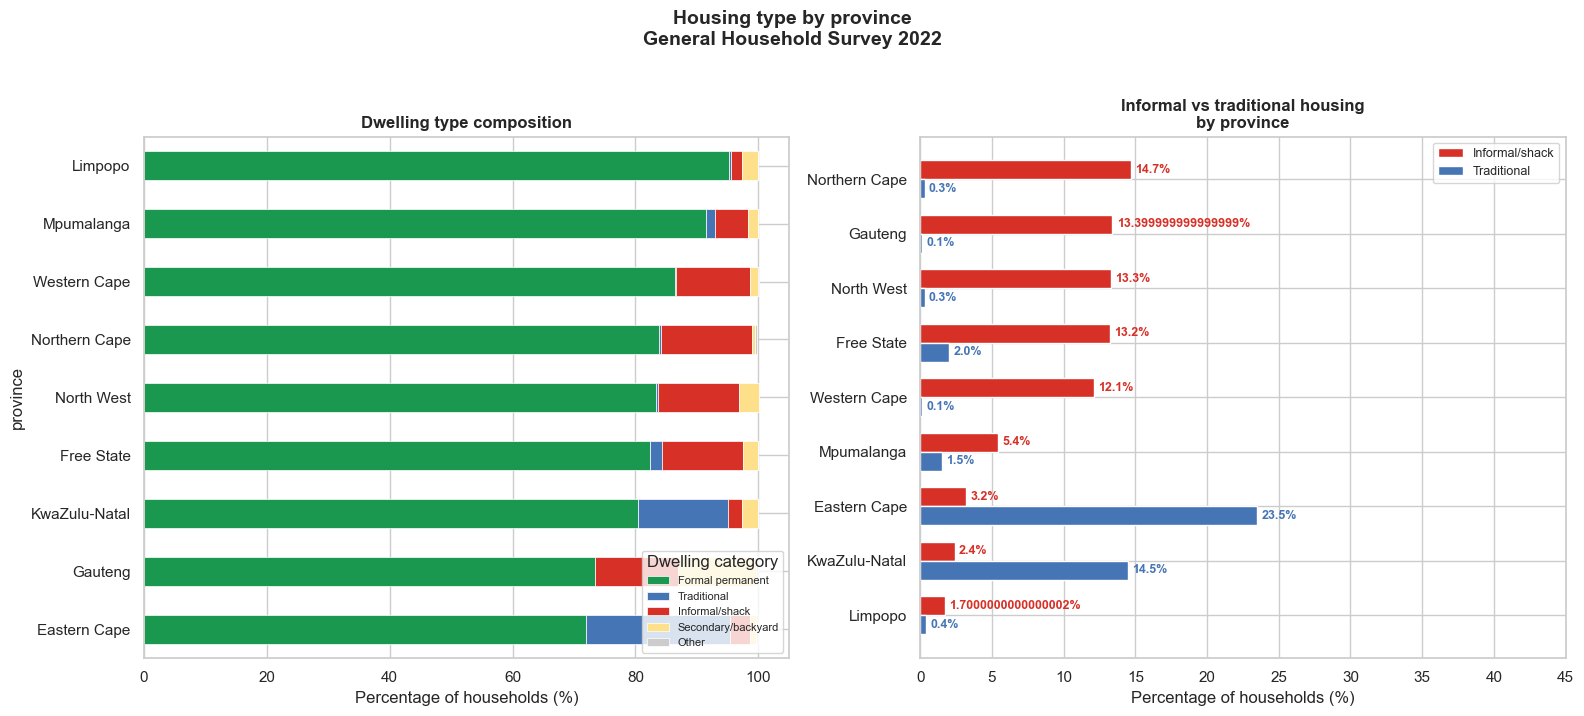


Formal housing percentage by province:
     province  percentage
      Limpopo        95.2
   Mpumalanga        91.5
 Western Cape        86.5
Northern Cape        83.9
   North West        83.3
   Free State        82.3
KwaZulu-Natal        80.5
      Gauteng        73.4
 Eastern Cape        71.9

Informal housing percentage by province:
     province  informal_pct  traditional_pct
Northern Cape          14.7              0.3
      Gauteng          13.4              0.1
   North West          13.3              0.3
   Free State          13.2              2.0
 Western Cape          12.1              0.1
   Mpumalanga           5.4              1.5
 Eastern Cape           3.2             23.5
KwaZulu-Natal           2.4             14.5
      Limpopo           1.7              0.4


In [23]:
# ============================================
# CHART 13 — Dwelling type composition
# by province
# ============================================

# Step 1 — Define categories
formal_dwelling = [
    'Dwelling/house or brick/concrete block structure on a separate stand or yard or on farm',
    'Flat or apartment in a block of flats',
    'Cluster house in complex',
    'Town house (semi-detached house in complex)',
    'Semi-detached house'
]

traditional_dwelling = [
    'Traditional dwelling/hut/structure made of traditional materials'
]

informal_dwelling = [
    'Informal dwelling/shack in backyard',
    'Informal dwelling/shack not in backyard; e.g. in an informal/squatter settlement or on farm'
]

secondary_dwelling = [
    'Dwelling/house/flat/room in backyard',
    "Room/flatlet on a property or a larger dwelling servants' quarters/granny flat",
    'Caravan/tent'
]

# Step 2 — Calculate percentages
province_totals_dt = dwelling_type.groupby(
    'province')['count'].sum()

dwelling_pct = dwelling_type.copy()
dwelling_pct['percentage'] = (
    dwelling_pct['count'] /
    dwelling_pct['province'].map(province_totals_dt) * 100
).round(1)

# Step 3 — Categorise
def categorise_dwelling(dwelling):
    if dwelling in formal_dwelling:
        return 'Formal permanent'
    elif dwelling in traditional_dwelling:
        return 'Traditional'
    elif dwelling in informal_dwelling:
        return 'Informal/shack'
    elif dwelling in secondary_dwelling:
        return 'Secondary/backyard'
    else:
        return 'Other'

dwelling_pct['dwelling_category'] = dwelling_pct[
    'dwelling_type'].apply(categorise_dwelling)

# Step 4 — Aggregate
dwelling_agg = dwelling_pct.groupby(
    ['province', 'dwelling_category']
)['percentage'].sum().reset_index()

# Pivot
dwelling_wide = dwelling_agg.pivot_table(
    index='province',
    columns='dwelling_category',
    values='percentage',
    fill_value=0
)

col_order = [
    'Formal permanent',
    'Traditional',
    'Informal/shack',
    'Secondary/backyard',
    'Other'
]
dwelling_wide = dwelling_wide.reindex(columns=col_order)

# Sort by formal permanent descending
dwelling_wide = dwelling_wide.sort_values(
    'Formal permanent', ascending=True)

# Step 5 — Build chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — stacked composition
colors_dwell = [
    '#1a9850',  # Formal — green
    '#4575b4',  # Traditional — blue
    '#d73027',  # Informal — red
    '#fee08b',  # Secondary — yellow
    '#cccccc'   # Other — grey
]

dwelling_wide.plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=colors_dwell,
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_xlabel('Percentage of households (%)')
axes[0].set_title(
    'Dwelling type composition',
    fontweight='bold'
)
axes[0].set_xlim(0, 105)
axes[0].legend(
    loc='lower right',
    fontsize=8,
    title='Dwelling category'
)

# Right — informal vs traditional detail
# These are the two most analytically interesting
# non-formal categories
informal_detail = dwelling_agg[
    dwelling_agg['dwelling_category'] == 'Informal/shack'
][['province', 'percentage']].rename(
    columns={'percentage': 'informal_pct'})

traditional_detail = dwelling_agg[
    dwelling_agg['dwelling_category'] == 'Traditional'
][['province', 'percentage']].rename(
    columns={'percentage': 'traditional_pct'})

housing_detail = informal_detail.merge(
    traditional_detail, on='province')

# Sort by informal percentage
housing_detail = housing_detail.sort_values(
    'informal_pct', ascending=True)

x = range(len(housing_detail))
bar_width = 0.35

bars1 = axes[1].barh(
    [i + bar_width/2 for i in x],
    housing_detail['informal_pct'],
    height=bar_width,
    color='#d73027',
    label='Informal/shack',
    edgecolor='white'
)

bars2 = axes[1].barh(
    [i - bar_width/2 for i in x],
    housing_detail['traditional_pct'],
    height=bar_width,
    color='#4575b4',
    label='Traditional',
    edgecolor='white'
)

for bar, pct in zip(bars1, housing_detail['informal_pct']):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center', fontsize=9, fontweight='bold',
        color='#d73027'
    )

for bar, pct in zip(bars2, housing_detail['traditional_pct']):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center', fontsize=9, fontweight='bold',
        color='#4575b4'
    )

axes[1].set_yticks(list(x))
axes[1].set_yticklabels(housing_detail['province'])
axes[1].set_xlabel('Percentage of households (%)')
axes[1].set_title(
    'Informal vs traditional housing\nby province',
    fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 45)

fig.suptitle(
    'Housing type by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart13_dwelling_type.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Print key tables
print("\nFormal housing percentage by province:")
formal_housing = dwelling_agg[
    dwelling_agg['dwelling_category'] == 'Formal permanent'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(formal_housing.to_string(index=False))

print("\nInformal housing percentage by province:")
print(housing_detail[['province', 'informal_pct',
                       'traditional_pct']]
      .sort_values('informal_pct', ascending=False)
      .to_string(index=False))

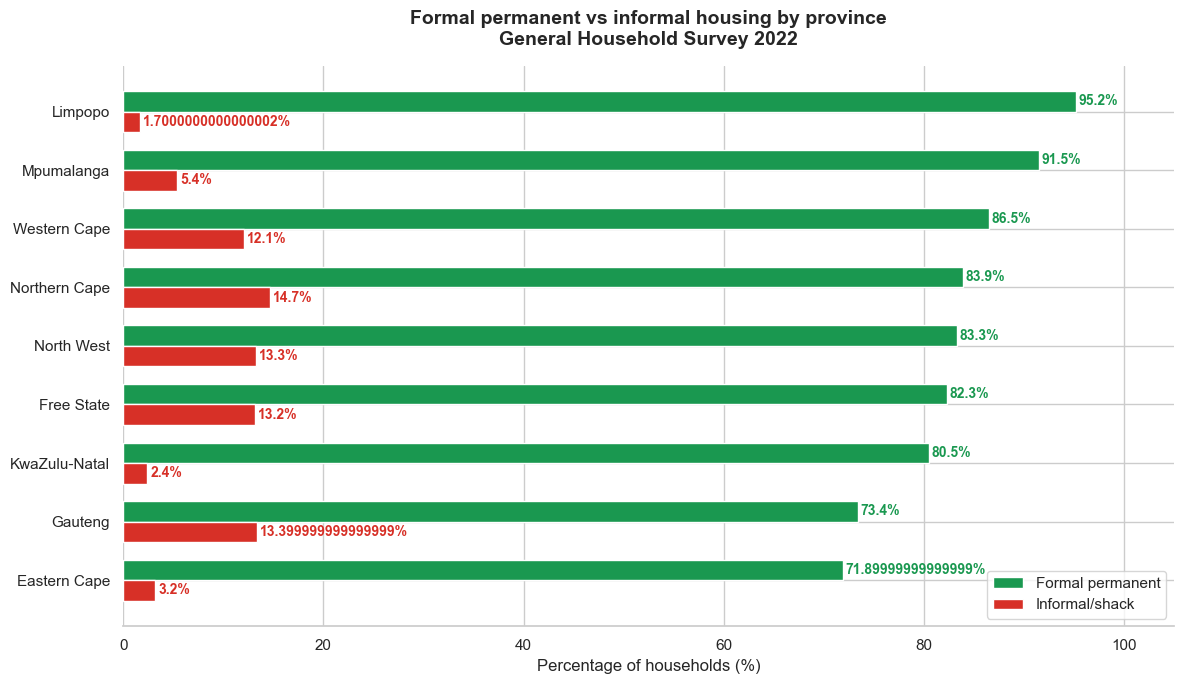


Formal vs Informal summary:
dwelling_category  Formal permanent  Informal/shack
province                                           
Limpopo                        95.2             1.7
Mpumalanga                     91.5             5.4
Western Cape                   86.5            12.1
Northern Cape                  83.9            14.7
North West                     83.3            13.3
Free State                     82.3            13.2
KwaZulu-Natal                  80.5             2.4
Gauteng                        73.4            13.4
Eastern Cape                   71.9             3.2


In [24]:
# ============================================
# CHART 13b — Formal vs Informal direct comparison
# ============================================

formal_vs_informal = dwelling_agg[
    dwelling_agg['dwelling_category'].isin([
        'Formal permanent', 'Informal/shack'])
].copy()

# Pivot
fvi_wide = formal_vs_informal.pivot_table(
    index='province',
    columns='dwelling_category',
    values='percentage',
    fill_value=0
)

# Sort by formal descending
fvi_wide = fvi_wide.sort_values(
    'Formal permanent', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.35
provinces = fvi_wide.index.tolist()
x = range(len(provinces))

bars1 = ax.barh(
    [i + bar_width/2 for i in x],
    fvi_wide['Formal permanent'],
    height=bar_width,
    color='#1a9850',
    label='Formal permanent',
    edgecolor='white'
)

bars2 = ax.barh(
    [i - bar_width/2 for i in x],
    fvi_wide['Informal/shack'],
    height=bar_width,
    color='#d73027',
    label='Informal/shack',
    edgecolor='white'
)

for bar, pct in zip(bars1, fvi_wide['Formal permanent']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center', fontsize=10,
        fontweight='bold', color='#1a9850'
    )

for bar, pct in zip(bars2, fvi_wide['Informal/shack']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center', fontsize=10,
        fontweight='bold', color='#d73027'
    )

ax.set_yticks(list(x))
ax.set_yticklabels(provinces)
ax.set_xlabel('Percentage of households (%)', fontsize=12)
ax.set_title(
    'Formal permanent vs informal housing by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.legend(fontsize=11)
ax.set_xlim(0, 105)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.savefig(
    '../outputs/chart13b_formal_vs_informal.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("\nFormal vs Informal summary:")
print(fvi_wide.sort_values(
    'Formal permanent', ascending=False)
    .to_string())

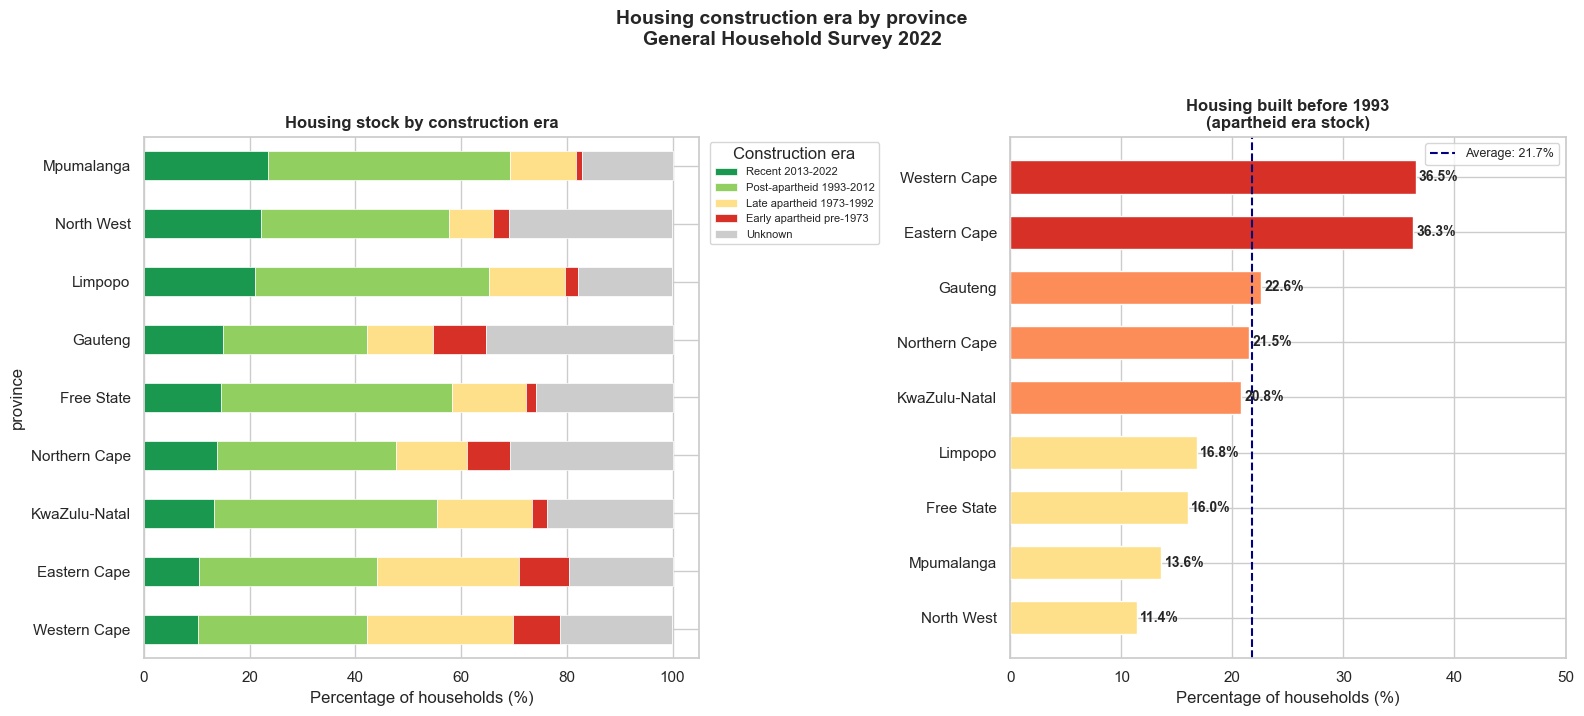


Recent construction (2013-2022) by province:
     province  percentage
   Mpumalanga        23.5
   North West        22.2
      Limpopo        21.1
      Gauteng        14.9
   Free State        14.5
Northern Cape        13.9
KwaZulu-Natal        13.3
 Eastern Cape        10.5
 Western Cape        10.3

Pre-1993 apartheid era housing by province:
     province  percentage
 Western Cape        36.5
 Eastern Cape        36.3
      Gauteng        22.6
Northern Cape        21.5
KwaZulu-Natal        20.8
      Limpopo        16.8
   Free State        16.0
   Mpumalanga        13.6
   North West        11.4

Post-apartheid RDP era (1993-2012) by province:
     province  percentage
   Mpumalanga        45.7
      Limpopo        44.2
   Free State        43.7
KwaZulu-Natal        42.1
   North West        35.5
Northern Cape        33.8
 Eastern Cape        33.6
 Western Cape        31.9
      Gauteng        27.3


In [25]:
# ============================================
# CHART 14 — Dwelling age by province
# ============================================

# Step 1 — Calculate percentages
province_totals_db = dwelling_built.groupby(
    'province')['count'].sum()

built_pct = dwelling_built.copy()
built_pct['percentage'] = (
    built_pct['count'] /
    built_pct['province'].map(province_totals_db) * 100
).round(1)

# Step 2 — Define era categories
def categorise_era(period):
    if period in ['2018–2022 (0–5 years)',
                  '2013–2017 (6–10 years)']:
        return 'Recent 2013-2022'
    elif period in ['2003–2012 (11–20 years)',
                    '1993–2002 (21–30 years)']:
        return 'Post-apartheid 1993-2012'
    elif period in ['1983–1992 (31–40 years)',
                    '1973–1982 (41–50 years)']:
        return 'Late apartheid 1973-1992'
    elif period in ['1951–1973 (51–70 years)',
                    'Prior to 1951']:
        return 'Early apartheid pre-1973'
    else:
        return 'Unknown'

built_pct['era'] = built_pct[
    'dwelling_period'].apply(categorise_era)

# Step 3 — Aggregate by era
era_agg = built_pct.groupby(
    ['province', 'era'])['percentage'].sum().reset_index()

# Pivot
era_wide = era_agg.pivot_table(
    index='province',
    columns='era',
    values='percentage',
    fill_value=0
)

col_order = [
    'Recent 2013-2022',
    'Post-apartheid 1993-2012',
    'Late apartheid 1973-1992',
    'Early apartheid pre-1973',
    'Unknown'
]
era_wide = era_wide.reindex(columns=col_order)

# Sort by recent construction descending
era_wide = era_wide.sort_values(
    'Recent 2013-2022', ascending=True)

# Step 4 — Build chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — stacked era composition
colors_era = [
    '#1a9850',  # Recent — green
    '#91cf60',  # Post-apartheid — light green
    '#fee08b',  # Late apartheid — yellow
    '#d73027',  # Early apartheid — red
    '#cccccc'   # Unknown — grey
]

era_wide.plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=colors_era,
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_xlabel('Percentage of households (%)')
axes[0].set_title(
    'Housing stock by construction era',
    fontweight='bold'
)
axes[0].set_xlim(0, 105)
axes[0].legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8,
    title='Construction era'
)

# Right — pre-1993 apartheid era housing
# as percentage of total known housing stock
# excluding Unknown category
pre_1993 = era_agg[
    era_agg['era'].isin([
        'Late apartheid 1973-1992',
        'Early apartheid pre-1973'
    ])
].groupby('province')['percentage'].sum().reset_index()

pre_1993 = pre_1993.sort_values(
    'percentage', ascending=True)

colors_pre = ['#d73027' if x > 30 else '#fc8d59'
              if x > 20 else '#fee08b'
              for x in pre_1993['percentage']]

bars = axes[1].barh(
    pre_1993['province'],
    pre_1993['percentage'],
    color=colors_pre,
    edgecolor='white',
    height=0.6
)

for bar, pct in zip(bars, pre_1993['percentage']):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', fontsize=10,
        fontweight='bold'
    )

axes[1].axvline(
    pre_1993['percentage'].mean(),
    color='navy',
    linestyle='--',
    linewidth=1.5,
    label=f'Average: {pre_1993["percentage"].mean():.1f}%'
)
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Percentage of households (%)')
axes[1].set_title(
    'Housing built before 1993\n(apartheid era stock)',
    fontweight='bold'
)
axes[1].set_xlim(0, 50)

fig.suptitle(
    'Housing construction era by province\n'
    'General Household Survey 2022',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/chart14_dwelling_age.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Print key tables
print("\nRecent construction (2013-2022) by province:")
recent = era_agg[
    era_agg['era'] == 'Recent 2013-2022'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(recent.to_string(index=False))

print("\nPre-1993 apartheid era housing by province:")
print(pre_1993.sort_values(
    'percentage', ascending=False)
    .to_string(index=False))

print("\nPost-apartheid RDP era (1993-2012) by province:")
rdp = era_agg[
    era_agg['era'] == 'Post-apartheid 1993-2012'
][['province', 'percentage']].sort_values(
    'percentage', ascending=False)
print(rdp.to_string(index=False))

## Key Finding — Housing Analysis

**Western Cape and Eastern Cape carry heaviest apartheid 
era housing burden at 36.5% and 36.3% respectively:**
Colonial and apartheid urban centres — Cape Town, Port Elizabeth,
East London — built substantial housing stock pre-1973 that
remains occupied today. Ranges from gentrified heritage 
property to ageing township infrastructure.

**RDP era (1993-2012) dominates former homeland provinces:**
Mpumalanga 45.7%, Limpopo 44.2%, Free State 43.7%.
Post-apartheid housing delivery programme was the primary
construction era for provinces excluded from apartheid
era urban development.

**Informal housing concentrated in economic opportunity provinces:**
Gauteng 13.4% and Western Cape 12.1% have highest informal
despite being wealthiest — driven by internal migration.
Limpopo 1.7% informal — not a migration destination,
stable long-term resident population.

**Traditional housing reflects cultural geography not poverty:**
Eastern Cape 23.5% traditional — former Transkei/Ciskei Xhosa
homeland areas. KZN 14.5% — rural Zulu areas.
Cultural choice on family communal land not infrastructure failure.

**Unknown construction era is itself a data signal:**
High unknown percentage in Eastern Cape and KZN correlates
with traditional housing — structures predate formal records.
DO NOT KNOW answer is a proxy for pre-formal tenure housing.

**Housing type driven by migration and culture more than 
governance — the dimension that most resists the simple
good governance equals good outcomes narrative.**

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

cleaned_path = '../data/cleaned/'

electricity_source = pd.read_csv(f'{cleaned_path}GHS2022_electricity_main_source_cleaned.csv')
electricity_access = pd.read_csv(f'{cleaned_path}GHS2022_electricity_access_cleaned.csv')
water_source = pd.read_csv(f'{cleaned_path}GHS2022_water_main_source_cleaned.csv', encoding='utf-8-sig')
water_supply = pd.read_csv(f'{cleaned_path}GHS2022_water_supply_cleaned.csv')
water_distance = pd.read_csv(f'{cleaned_path}GHS2022_water_distance_cleaned.csv', encoding='utf-8-sig')
toilet_type = pd.read_csv(f'{cleaned_path}GHS2022_toilet_type_cleaned.csv')
toilet_distance = pd.read_csv(f'{cleaned_path}GHS2022_toilet_distance_cleaned.csv')
refuse_removal = pd.read_csv(f'{cleaned_path}GHS2022_refuse_removal_cleaned.csv')
refuse_irregular = pd.read_csv(f'{cleaned_path}GHS2022_refuse_irregular_cleaned.csv')
handwashing = pd.read_csv(f'{cleaned_path}GHS2022_handwashing_cleaned.csv')
dwelling_type = pd.read_csv(f'{cleaned_path}GHS2022_dwelling_type_cleaned.csv')
dwelling_built = pd.read_csv(f'{cleaned_path}GHS2022_dwelling_built_cleaned.csv')
littering = pd.read_csv(f'{cleaned_path}GHS2022_littering_cleaned.csv')

print("All datasets loaded. Ready to build master heatmap.")

All datasets loaded. Ready to build master heatmap.


In [27]:
# ============================================
# MASTER HEATMAP — DATA ASSEMBLY
# ============================================

# We need one number per province per metric
# All numbers represent "higher is better" after inversion

provinces_order = [
    'Western Cape', 'Gauteng', 'Free State',
    'Northern Cape', 'North West', 'KwaZulu-Natal',
    'Mpumalanga', 'Eastern Cape', 'Limpopo'
]

# ---- REFUSE ----
# Municipal weekly collection %
refuse_weekly = refuse_removal.copy()
prov_tot_rr = refuse_removal.groupby('province')['count'].sum()
refuse_weekly['pct'] = (refuse_weekly['count'] /
    refuse_weekly['province'].map(prov_tot_rr) * 100).round(1)
refuse_weekly_pct = refuse_weekly[
    refuse_weekly['refuse_type'] ==
    'Removed by local authority/private company at least once a week'
][['province', 'pct']].rename(columns={'pct': 'refuse_weekly'})

# Irregular removal % — inverted
refuse_irr = refuse_irregular.copy()
prov_tot_ri = refuse_irregular.groupby('province')['count'].sum()
refuse_irr['pct'] = (refuse_irr['count'] /
    refuse_irr['province'].map(prov_tot_ri) * 100).round(1)
refuse_irr_pct = refuse_irr[
    refuse_irr['refuse_irregular'] == 'Yes'
][['province', 'pct']].copy()
refuse_irr_pct['refuse_reliability'] = (
    100 - refuse_irr_pct['pct']).round(1)
refuse_irr_pct = refuse_irr_pct[
    ['province', 'refuse_reliability']]

# ---- WATER ----
# Supply confirmation %
prov_tot_ws = water_supply.groupby('province')['count'].sum()
ws_pct = water_supply.copy()
ws_pct['pct'] = (ws_pct['count'] /
    ws_pct['province'].map(prov_tot_ws) * 100).round(1)
water_supply_pct = ws_pct[
    ws_pct['water_supply'] == 'Yes'
][['province', 'pct']].rename(columns={'pct': 'water_supply_pct'})

# Unsafe water % — inverted
water_source['safety_category'] = water_source[
    'water_source'].apply(lambda x:
    'unsafe' if x in [
        'Flowing water/stream/river',
        'Stagnant water/dam/pool',
        'Well', 'Spring',
        'Other source of drinking water'
    ] else 'safe')
prov_tot_wsrc = water_source.groupby('province')['count'].sum()
wsrc_pct = water_source.copy()
wsrc_pct['pct'] = (wsrc_pct['count'] /
    wsrc_pct['province'].map(prov_tot_wsrc) * 100).round(1)
unsafe_water = wsrc_pct[
    wsrc_pct['safety_category'] == 'unsafe'
].groupby('province')['pct'].sum().reset_index()
unsafe_water['water_safety'] = (
    100 - unsafe_water['pct']).round(1)
unsafe_water = unsafe_water[['province', 'water_safety']]

# ---- SANITATION ----
# Safe sanitation %
safe_san_list = [
    'Flush toilet connected to a public sewerage system',
    'Flush toilet connected to a septic tank or conservancy tank',
    'Pour bucket-flush toilet connected to a septic tank (or septic pit)'
]
prov_tot_tt = toilet_type.groupby('province')['count'].sum()
tt_pct = toilet_type.copy()
tt_pct['pct'] = (tt_pct['count'] /
    tt_pct['province'].map(prov_tot_tt) * 100).round(1)
safe_sanitation = tt_pct[
    tt_pct['toilet_type'].isin(safe_san_list)
].groupby('province')['pct'].sum().reset_index()
safe_sanitation = safe_sanitation.rename(
    columns={'pct': 'safe_sanitation'})

# Open defecation % — inverted
open_def = tt_pct[
    tt_pct['toilet_type'] ==
    'Open defecation (e.g. no facilities; field; bush)'
][['province', 'pct']].copy()
open_def['no_open_defecation'] = (
    100 - open_def['pct']).round(1)
open_def = open_def[['province', 'no_open_defecation']]

# ---- HANDWASHING ----
hw_filtered = handwashing[
    handwashing['handwashing_facility'].isin(
        ['Yes', 'No', 'Do not know'])].copy()
prov_tot_hw = hw_filtered.groupby('province')['count'].sum()
hw_pct = hw_filtered.copy()
hw_pct['pct'] = (hw_pct['count'] /
    hw_pct['province'].map(prov_tot_hw) * 100).round(1)
handwashing_pct = hw_pct[
    hw_pct['handwashing_facility'] == 'Yes'
][['province', 'pct']].rename(
    columns={'pct': 'handwashing'})

# ---- ELECTRICITY ----
prov_tot_ea = electricity_access.groupby(
    'province')['count'].sum()
ea_pct = electricity_access.copy()
ea_pct['pct'] = (ea_pct['count'] /
    ea_pct['province'].map(prov_tot_ea) * 100).round(1)
elec_access_pct = ea_pct[
    ea_pct['electricity_access'] == 'Yes'
][['province', 'pct']].rename(
    columns={'pct': 'electricity_access'})

# ---- HOUSING ----
# Formal permanent %
formal_list = [
    'Dwelling/house or brick/concrete block structure on a separate stand or yard or on farm',
    'Flat or apartment in a block of flats',
    'Cluster house in complex',
    'Town house (semi-detached house in complex)',
    'Semi-detached house'
]
prov_tot_dt = dwelling_type.groupby('province')['count'].sum()
dt_pct = dwelling_type.copy()
dt_pct['pct'] = (dt_pct['count'] /
    dt_pct['province'].map(prov_tot_dt) * 100).round(1)
formal_housing = dt_pct[
    dt_pct['dwelling_type'].isin(formal_list)
].groupby('province')['pct'].sum().reset_index()
formal_housing = formal_housing.rename(
    columns={'pct': 'formal_housing'})

# Pre-1993 housing % — inverted
pre1993_list = [
    '1983–1992 (31–40 years)',
    '1973–1982 (41–50 years)',
    '1951–1973 (51–70 years)',
    'Prior to 1951'
]
prov_tot_db = dwelling_built.groupby('province')['count'].sum()
db_pct = dwelling_built.copy()
db_pct['pct'] = (db_pct['count'] /
    db_pct['province'].map(prov_tot_db) * 100).round(1)
pre1993 = db_pct[
    db_pct['dwelling_period'].isin(pre1993_list)
].groupby('province')['pct'].sum().reset_index()
pre1993['new_housing_ratio'] = (
    100 - pre1993['pct']).round(1)
pre1993 = pre1993[['province', 'new_housing_ratio']]

# ============================================
# MERGE ALL METRICS INTO ONE DATAFRAME
# ============================================
heatmap_df = refuse_weekly_pct.copy()

for df in [
    refuse_irr_pct,
    water_supply_pct,
    unsafe_water,
    safe_sanitation,
    open_def,
    handwashing_pct,
    elec_access_pct,
    formal_housing,
    pre1993
]:
    heatmap_df = heatmap_df.merge(df, on='province')

# Set province as index and reorder
heatmap_df = heatmap_df.set_index('province')
heatmap_df = heatmap_df.reindex(provinces_order)

print("Heatmap data assembled:")
print(heatmap_df.round(1).to_string())
print(f"\nShape: {heatmap_df.shape}")

Heatmap data assembled:
               refuse_weekly  refuse_reliability  water_supply_pct  water_safety  safe_sanitation  no_open_defecation  handwashing  electricity_access  formal_housing  new_housing_ratio
province                                                                                                                                                                                 
Western Cape            88.5                91.7              90.5          99.9             96.2                99.7         82.6                98.5            86.5               63.5
Gauteng                 79.7                87.0              93.1          99.9             89.4                99.9         82.7                94.4            73.4               77.4
Free State              64.9                41.3              91.7          99.4             79.2                99.2         70.4                95.9            82.3               84.0
Northern Cape           58.5                64

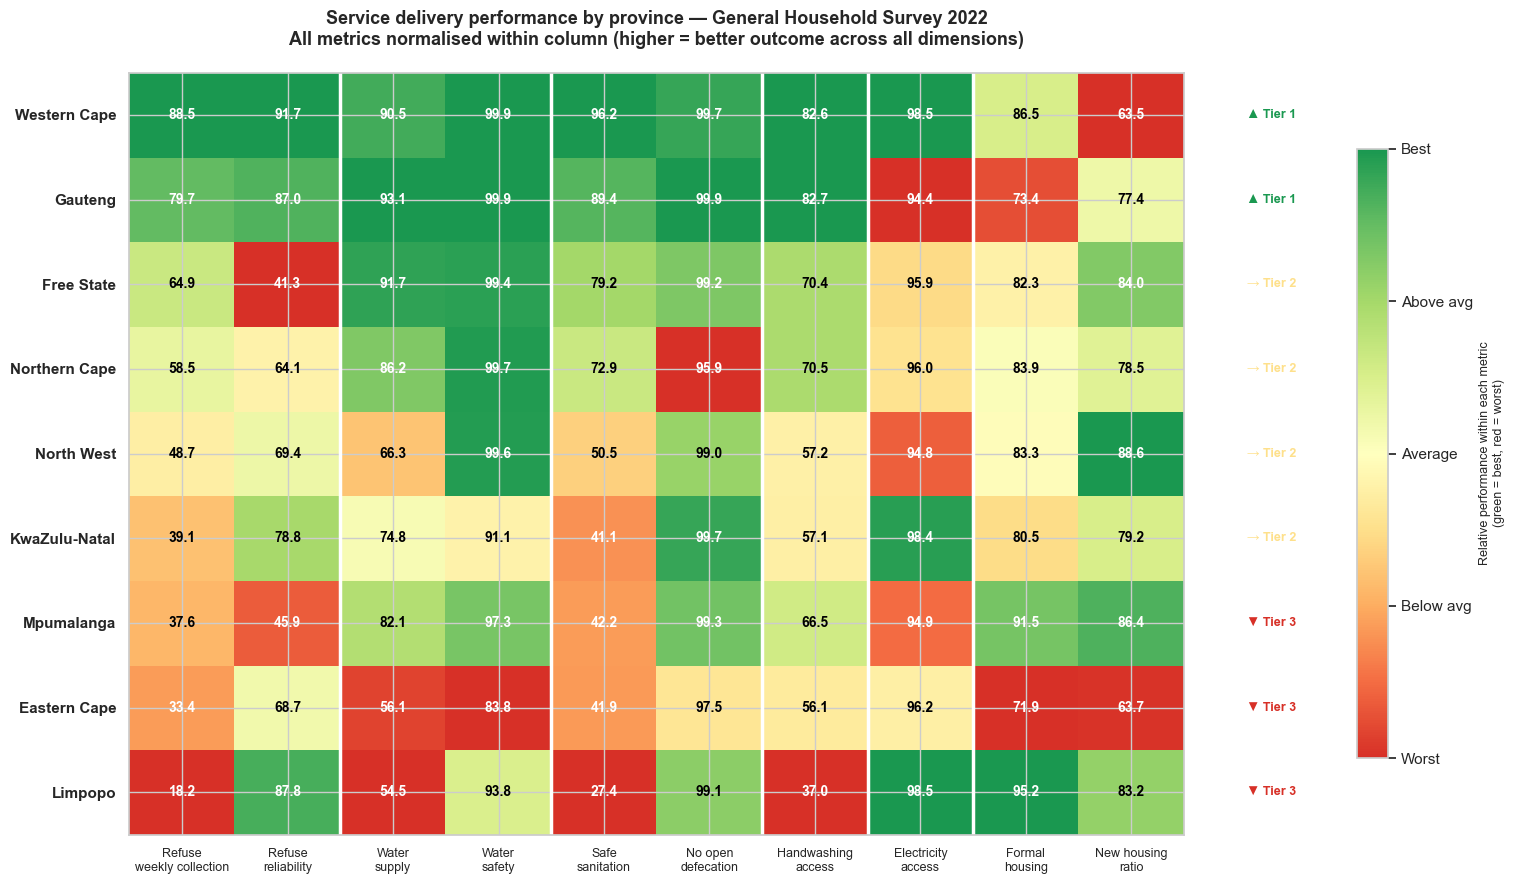


Province tier summary:
  Western Cape: 85.1 average score
  Gauteng: 73.0 average score
  Free State: 65.4 average score
  Northern Cape: 57.3 average score
  North West: 54.2 average score
  KwaZulu-Natal: 55.8 average score
  Mpumalanga: 55.1 average score
  Eastern Cape: 22.8 average score
  Limpopo: 51.3 average score


In [28]:
# ============================================
# MASTER HEATMAP — SERVICE DELIVERY 2022
# ============================================

import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Step 1 — Rename columns for display
display_names = {
    'refuse_weekly': 'Refuse\nweekly collection',
    'refuse_reliability': 'Refuse\nreliability',
    'water_supply_pct': 'Water\nsupply',
    'water_safety': 'Water\nsafety',
    'safe_sanitation': 'Safe\nsanitation',
    'no_open_defecation': 'No open\ndefecation',
    'handwashing': 'Handwashing\naccess',
    'electricity_access': 'Electricity\naccess',
    'formal_housing': 'Formal\nhousing',
    'new_housing_ratio': 'New housing\nratio'
}

heatmap_display = heatmap_df.rename(columns=display_names)

# Step 2 — Normalise each column to 0-100 scale
# relative to min and max within that column
# This ensures colour comparison is within each metric
# not across metrics with different scales
heatmap_normalised = heatmap_display.copy()
for col in heatmap_display.columns:
    col_min = heatmap_display[col].min()
    col_max = heatmap_display[col].max()
    if col_max > col_min:
        heatmap_normalised[col] = (
            (heatmap_display[col] - col_min) /
            (col_max - col_min) * 100
        ).round(1)
    else:
        heatmap_normalised[col] = 50

# Step 3 — Build the heatmap
fig, ax = plt.subplots(figsize=(16, 9))

# Custom colormap — deep red to deep green
colors_map = ['#d73027', '#f46d43', '#fdae61',
              '#fee08b', '#ffffbf', '#d9ef8b',
              '#a6d96a', '#66bd63', '#1a9850']
cmap = LinearSegmentedColormap.from_list(
    'rdylgn', colors_map, N=256)

# Plot heatmap using normalised values for colour
# but display actual values in cells
im = ax.imshow(
    heatmap_normalised.values,
    cmap=cmap,
    aspect='auto',
    vmin=0,
    vmax=100
)

# Add actual value annotations
for i in range(len(heatmap_display.index)):
    for j in range(len(heatmap_display.columns)):
        val = heatmap_display.iloc[i, j]
        norm_val = heatmap_normalised.iloc[i, j]

        # Choose text colour based on background
        text_color = 'white' if norm_val < 25 or norm_val > 80 else 'black'

        ax.text(
            j, i, f'{val:.1f}',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color=text_color
        )

# Formatting
ax.set_xticks(range(len(heatmap_display.columns)))
ax.set_xticklabels(
    heatmap_display.columns,
    fontsize=9,
    ha='center'
)

ax.set_yticks(range(len(heatmap_display.index)))
ax.set_yticklabels(
    heatmap_display.index,
    fontsize=11,
    fontweight='bold'
)

# Add column group labels above chart
group_positions = {
    'REFUSE': (0.5, 2),
    'WATER': (2.5, 2),
    'SANITATION': (4.5, 2),
    'HW': (6.5, 1),
    'ELEC': (7.5, 1),
    'HOUSING': (8.5, 2)
}

# Add subtle column dividers between dimensions
dividers = [1.5, 3.5, 5.5, 6.5, 7.5]
for d in dividers:
    ax.axvline(x=d, color='white', linewidth=2.5)

# Add province tier labels on right side
tier_labels = {
    'Western Cape': '▲ Tier 1',
    'Gauteng': '▲ Tier 1',
    'Free State': '→ Tier 2',
    'Northern Cape': '→ Tier 2',
    'North West': '→ Tier 2',
    'KwaZulu-Natal': '→ Tier 2',
    'Mpumalanga': '▼ Tier 3',
    'Eastern Cape': '▼ Tier 3',
    'Limpopo': '▼ Tier 3'
}

for i, province in enumerate(heatmap_display.index):
    tier = tier_labels[province]
    color = '#1a9850' if 'Tier 1' in tier else \
            '#fee08b' if 'Tier 2' in tier else '#d73027'
    ax.text(
        len(heatmap_display.columns) + 0.1,
        i,
        tier,
        va='center',
        fontsize=9,
        color=color,
        fontweight='bold'
    )

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.12)
cbar.set_label(
    'Relative performance within each metric\n'
    '(green = best, red = worst)',
    fontsize=9
)
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.set_ticklabels([
    'Worst', 'Below avg',
    'Average', 'Above avg', 'Best'
])

ax.set_title(
    'Service delivery performance by province — '
    'General Household Survey 2022\n'
    'All metrics normalised within column '
    '(higher = better outcome across all dimensions)',
    fontsize=13,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig(
    '../outputs/master_heatmap_2022.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("\nProvince tier summary:")
for province in heatmap_display.index:
    row_mean = heatmap_normalised.loc[province].mean()
    print(f"  {province}: {row_mean:.1f} average score")

In [29]:
# ============================================
# DEVELOPMENT EFFICIENCY SCORE (DES)
# General Household Survey 2022
# ============================================

# Step 1 — Define weights
weights = {
    'refuse_weekly':        0.10,
    'refuse_reliability':   0.10,
    'water_supply_pct':     0.15,
    'water_safety':         0.15,
    'safe_sanitation':      0.15,
    'no_open_defecation':   0.15,
    'handwashing':          0.05,
    'electricity_access':   0.05,
    'formal_housing':       0.05,
    'new_housing_ratio':    0.05
}

# Verify weights sum to 1.0
print(f"Weights sum: {sum(weights.values())}")

# Step 2 — Normalise each metric
# Same min-max normalisation as heatmap
des_normalised = heatmap_df.copy()

for col in des_normalised.columns:
    col_min = des_normalised[col].min()
    col_max = des_normalised[col].max()
    if col_max > col_min:
        des_normalised[col] = (
            (des_normalised[col] - col_min) /
            (col_max - col_min) * 100
        ).round(4)
    else:
        des_normalised[col] = 50

# Step 3 — Calculate weighted DES score
des_scores = pd.DataFrame(index=heatmap_df.index)

for metric, weight in weights.items():
    des_scores[metric] = (
        des_normalised[metric] * weight
    )

# Sum weighted scores
des_scores['DES'] = des_scores.sum(axis=1).round(2)

# Add raw scores for reference
des_scores['DES_rounded'] = des_scores['DES'].round(1)

# Sort by DES descending
des_final = des_scores[['DES']].sort_values(
    'DES', ascending=False)

print("\nDevelopment Efficiency Score 2022:")
print("=" * 40)
for province, row in des_final.iterrows():
    score = row['DES']
    bar = '█' * int(score / 5)
    print(f"{province:<20} {score:>5.1f}  {bar}")

print("\nNational average DES:", 
      des_final['DES'].mean().round(1))
print("Highest:", des_final['DES'].max(),
      "-", des_final['DES'].idxmax())
print("Lowest:", des_final['DES'].min(),
      "-", des_final['DES'].idxmin())
print("Gap between best and worst:",
      (des_final['DES'].max() - 
       des_final['DES'].min()).round(1))

Weights sum: 1.0

Development Efficiency Score 2022:
Western Cape          91.4  ██████████████████
Gauteng               84.4  ████████████████
Free State            71.1  ██████████████
Northern Cape         58.5  ███████████
North West            56.0  ███████████
Mpumalanga            55.6  ███████████
KwaZulu-Natal         54.4  ██████████
Limpopo               44.5  ████████
Eastern Cape          21.7  ████

National average DES: 59.7
Highest: 91.36 - Western Cape
Lowest: 21.71 - Eastern Cape
Gap between best and worst: 69.6


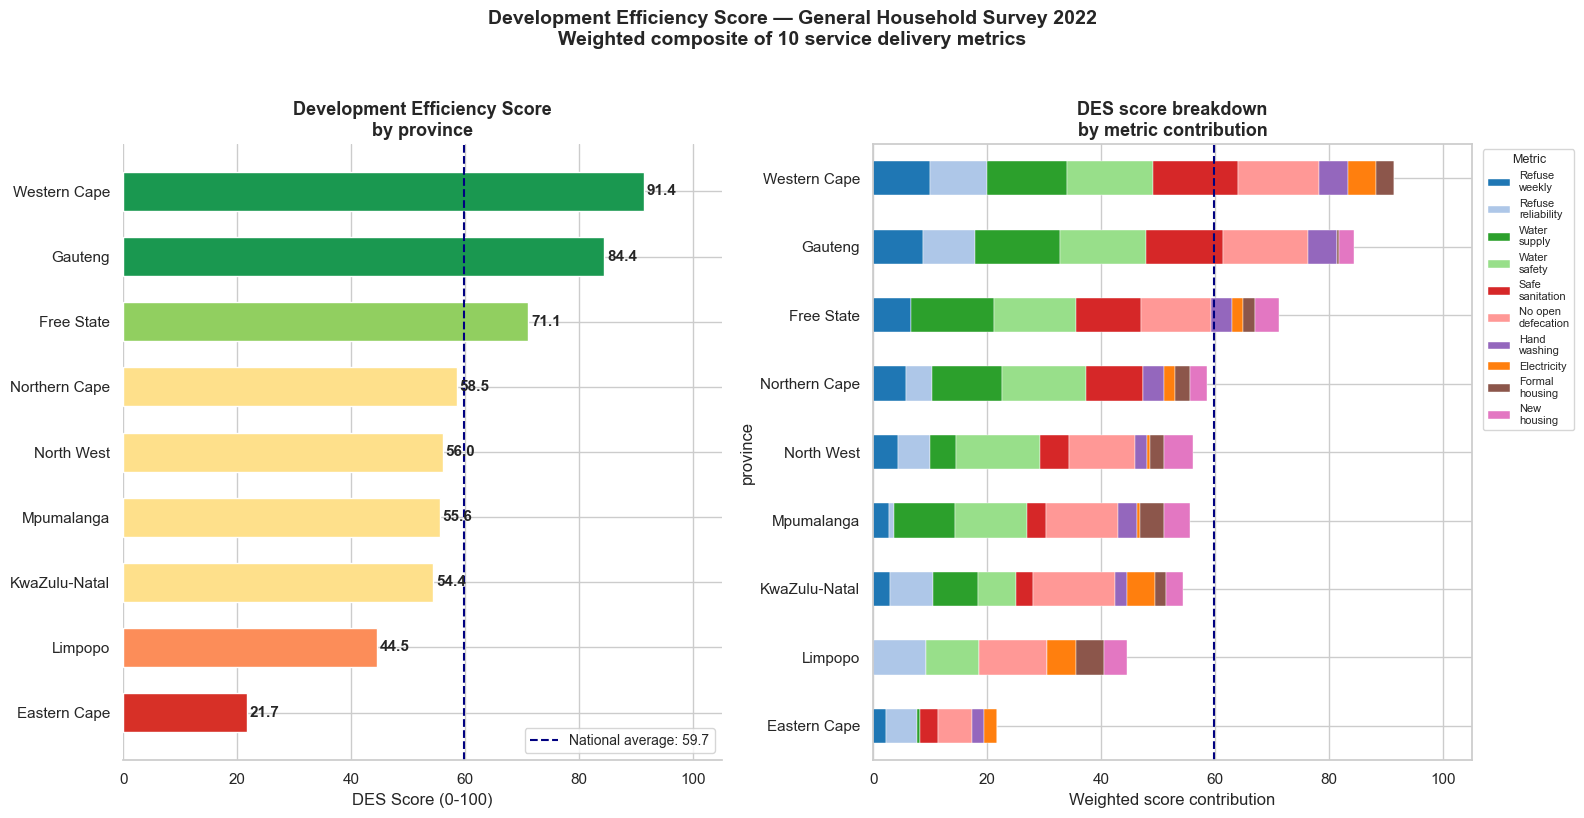

DES scores saved to outputs/DES_scores_2022.csv


In [30]:
# ============================================
# DES VISUALISATION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left — DES bar chart
des_plot = des_final.sort_values('DES', ascending=True)

colors_des = []
for score in des_plot['DES']:
    if score >= 80:
        colors_des.append('#1a9850')
    elif score >= 65:
        colors_des.append('#91cf60')
    elif score >= 50:
        colors_des.append('#fee08b')
    elif score >= 35:
        colors_des.append('#fc8d59')
    else:
        colors_des.append('#d73027')

bars = axes[0].barh(
    des_plot.index,
    des_plot['DES'],
    color=colors_des,
    edgecolor='white',
    height=0.6
)

for bar, score in zip(bars, des_plot['DES']):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.1f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

national_avg = des_final['DES'].mean()
axes[0].axvline(
    national_avg,
    color='navy',
    linestyle='--',
    linewidth=1.5,
    label=f'National average: {national_avg:.1f}'
)
axes[0].legend(fontsize=10)
axes[0].set_xlabel('DES Score (0-100)', fontsize=12)
axes[0].set_title(
    'Development Efficiency Score\nby province',
    fontweight='bold',
    fontsize=13
)
axes[0].set_xlim(0, 105)
sns.despine(ax=axes[0], left=True)

# Right — weighted contribution breakdown
# Show what is driving each province's score
contribution_cols = [
    'refuse_weekly', 'refuse_reliability',
    'water_supply_pct', 'water_safety',
    'safe_sanitation', 'no_open_defecation',
    'handwashing', 'electricity_access',
    'formal_housing', 'new_housing_ratio'
]

short_labels = [
    'Refuse\nweekly', 'Refuse\nreliability',
    'Water\nsupply', 'Water\nsafety',
    'Safe\nsanitation', 'No open\ndefecation',
    'Hand\nwashing', 'Electricity', 
    'Formal\nhousing', 'New\nhousing'
]

# Get contribution per metric for each province
contributions = des_scores[contribution_cols].copy()
contributions.columns = short_labels
contributions = contributions.reindex(
    des_plot.index)

colors_contrib = [
    '#1f77b4', '#aec7e8',
    '#2ca02c', '#98df8a',
    '#d62728', '#ff9896',
    '#9467bd', '#ff7f0e',
    '#8c564b', '#e377c2'
]

contributions.plot(
    kind='barh',
    stacked=True,
    ax=axes[1],
    color=colors_contrib,
    edgecolor='white',
    linewidth=0.3
)

axes[1].set_xlabel('Weighted score contribution', fontsize=12)
axes[1].set_title(
    'DES score breakdown\nby metric contribution',
    fontweight='bold',
    fontsize=13
)
axes[1].set_xlim(0, 105)
axes[1].legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8,
    title='Metric',
    title_fontsize=9
)
axes[1].axvline(
    national_avg,
    color='navy',
    linestyle='--',
    linewidth=1.5
)

fig.suptitle(
    'Development Efficiency Score — '
    'General Household Survey 2022\n'
    'Weighted composite of 10 service delivery metrics',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/DES_score_2022.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# Save DES scores to CSV for future use
des_export = des_final.copy()
des_export['year'] = 2022
des_export.to_csv(
    '../outputs/DES_scores_2022.csv')

print("DES scores saved to outputs/DES_scores_2022.csv")

## Development Efficiency Score — Final Results 2022

**Methodology:**
Weighted composite of 10 service delivery metrics.
All metrics normalised 0-100 within column before weighting.
Weights reflect public health impact hierarchy.

**Weights applied:**
- Safe sanitation: 15%
- Water supply: 15%  
- Water safety: 15%
- No open defecation: 15%
- Refuse weekly: 10%
- Refuse reliability: 10%
- Handwashing: 5%
- Electricity access: 5%
- Formal housing: 5%
- New housing ratio: 5%

**Results:**
1. Western Cape    91.4  ▲ Tier 1
2. Gauteng         84.4  ▲ Tier 1
3. Free State      71.1  → Tier 2
4. Northern Cape   58.5  → Tier 2
5. North West      56.0  → Tier 2
6. Mpumalanga      55.6  → Tier 2
7. KwaZulu-Natal   54.4  → Tier 2
8. Limpopo         44.5  ▼ Tier 3
9. Eastern Cape    21.7  ▼ Tier 3

National average: 59.7
Gap best to worst: 69.6 points

**Key insight:**
6 of 9 provinces fall below the national average —
the average is inflated by two high performing outliers.
Median DES of 55.6 (Mpumalanga) is more representative
of the typical South African household's service
delivery experience.

**Limitation:**
Provincial averages mask internal municipal inequality.
Phase 2 municipal level analysis required for accurate
picture of service delivery distribution within provinces.
Weights reflect public health priorities — alternative
weighting frameworks would produce different rankings.